# Bike Rental Prediction – Machine Learning Analysis

## Goals

This project analyzes a dataset of bike rentals and develops predictive models using:
- Exploratory Data Analysis (EDA)
- Ordinary Least Squares (OLS) regression on log-transformed target
- Ridge regression with hyperparameter tuning
- Cross-validation and learning curves
- A non-linear model (Random Forest or Neural Network)
- Final evaluation, discussion, limitations & future work

The objective is to create a clear, self-contained notebook demonstrating the full ML workflow.

In [1]:
# file and data handling
from pathlib import Path
import pandas as pd
import numpy as np

# plotting
import matplotlib.pyplot as plt
import seaborn as sns

# model selection and evaluation
from sklearn.model_selection import (
    train_test_split,
    cross_val_score,
    GridSearchCV,
    RandomizedSearchCV,
    learning_curve
)
from sklearn.metrics import root_mean_squared_error, r2_score

# models
from sklearn.linear_model import LinearRegression, PoissonRegressor, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor

# preprocessing and pipelines
from sklearn.preprocessing import StandardScaler, OneHotEncoder, FunctionTransformer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.impute import SimpleImputer

# other ml libraries
import xgboost as xgb


---

# 2. Data Loading and Cleaning


In this section, we load both datasets separately, inspect their structure, and perform initial preprocessing:

### Bike Counter Dataset (`train.parquet`)
- Bike rental counts at various counting stations
- Location data (latitude, longitude)
- Temporal information

### Weather Dataset (`external_data.csv`)
- Temperature, humidity, wind speed
- Precipitation, atmospheric pressure
- Weather conditions

For each dataset, we will:
- Check data types and structure
- Handle missing values
- Extract datetime features (hour, day, month, etc.)

## 2.1 Bike Counter Dataset

In [2]:
# Load bike counter data
bike_data = pd.read_parquet(Path("data") / "train.parquet")
bike_data.head()

,counter_id,counter_name,site_id,site_name,bike_count,date,counter_installation_date,coordinates,counter_technical_id,latitude,longitude,log_bike_count
48321,100007049-102007049,28 boulevard Diderot E-O,100007049,28 boulevard Diderot,0.0,2020-09-01 02:00:00,2013-01-18,"48.846028,2.375429",Y2H15027244,48.846028,2.375429,0.000000
48324,100007049-102007049,28 boulevard Diderot E-O,100007049,28 boulevard Diderot,1.0,2020-09-01 03:00:00,2013-01-18,"48.846028,2.375429",Y2H15027244,48.846028,2.375429,0.693147
48327,100007049-102007049,28 boulevard Diderot E-O,100007049,28 boulevard Diderot,0.0,2020-09-01 04:00:00,2013-01-18,"48.846028,2.375429",Y2H15027244,48.846028,2.375429,0.000000
48330,100007049-102007049,28 boulevard Diderot E-O,100007049,28 boulevard Diderot,4.0,2020-09-01 15:00:00,2013-01-18,"48.846028,2.375429",Y2H15027244,48.846028,2.375429,1.609438
48333,100007049-102007049,28 boulevard Diderot E-O,100007049,28 boulevard Diderot,9.0,2020-09-01 18:00:00,2013-01-18,"48.846028,2.375429",Y2H15027244,48.846028,2.375429,2.302585


One may observe that the dataset countains two sets of bike_counts, one has an applied logarithmic scale to the bike count.
This could have been done in the past due to mutiple reasons: 
- Handle skewness: Traffic data is often characterized by hours with low to zero observations (nights, very cold, rainy weather) and hours with a high frequency (rush hour, sunnny, ...)
- reduce variance
- Mitigate the effect of events such as public holidays, sunny weather or public events on the forecasting model 

the logarithmic manipulation is applied by

$
\log(bike count + 1)
$

the + 1 is applied to make the calculation feasible for bike_counts == 0


In [3]:
bike_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 496827 entries, 48321 to 929187
Data columns (total 12 columns):
 #   Column                     Non-Null Count   Dtype         
---  ------                     --------------   -----         
 0   counter_id                 496827 non-null  category      
 1   counter_name               496827 non-null  category      
 2   site_id                    496827 non-null  int64         
 3   site_name                  496827 non-null  category      
 4   bike_count                 496827 non-null  float64       
 5   date                       496827 non-null  datetime64[us]
 6   counter_installation_date  496827 non-null  datetime64[us]
 7   coordinates                496827 non-null  category      
 8   counter_technical_id       496827 non-null  category      
 9   latitude                   496827 non-null  float64       
 10  longitude                  496827 non-null  float64       
 11  log_bike_count             496827 non-null  float64  

In [4]:
bike_data.describe()

,site_id,bike_count,date,counter_installation_date,latitude,longitude,log_bike_count
count,4.968270e+05,496827.000000,496827,496827,496827.000000,496827.000000,496827.000000
mean,1.053450e+08,60.191475,2021-03-08 07:25:59.668858,2019-04-04 07:24:35.245911,48.854343,2.345479,3.079917
min,1.000070e+08,0.000000,2020-09-01 01:00:00,2013-01-18 00:00:00,48.826360,2.265420,0.000000
25%,1.000475e+08,5.000000,2020-12-05 22:00:00,2018-11-29 00:00:00,48.840801,2.314440,1.791759
50%,1.000562e+08,29.000000,2021-03-08 11:00:00,2019-11-06 00:00:00,48.852090,2.353870,3.401197
75%,1.000563e+08,79.000000,2021-06-09 14:00:00,2019-12-11 00:00:00,48.864610,2.375870,4.382027
max,3.000147e+08,1302.000000,2021-09-09 23:00:00,2020-11-29 00:00:00,48.891720,2.409690,7.172425
std,3.210346e+07,87.590566,NaN,NaN,0.018554,0.038026,1.659899


In [5]:
print("Missing values in bike data")
print(bike_data.isna().sum())



Missing values in bike data
counter_id                   0
counter_name                 0
site_id                      0
site_name                    0
bike_count                   0
date                         0
counter_installation_date    0
coordinates                  0
counter_technical_id         0
latitude                     0
longitude                    0
log_bike_count               0
dtype: int64


**Observations:**
- No missing values in the bike counter dataset
- 496,827 hourly observations across 56 counters at 30 unique locations
- Target variable: `bike_count` (also available as `log_bike_count`)

In [6]:
import holidays

# Define French holidays
FR_holidays = holidays.FR(years=range(2019, 2022))

bike_data["FR_holidays"] = bike_data["date"].dt.date.isin(FR_holidays).astype(int)
print(f"Number of rows marked as holidays: {bike_data['FR_holidays'].sum()}")

Number of rows marked as holidays: 14688


14688 data inputs are marked as holiday in the total dataset

### Extract Datetime Features

Extract temporal components from the `date` column for later analysis and modeling.

In [7]:
def encode_dates(X):
    X = X.copy()  # Ensure we're working on a copy
    # Encode the date information
    X["year"] = X["date"].dt.year
    X["month"] = X["date"].dt.month
    X["day"] = X["date"].dt.day
    X["weekday"] = X["date"].dt.weekday  # 0=Monday, 6=Sunday
    X["hour"] = X["date"].dt.hour

    # add weekend column
    X["weekend"] = X["weekday"].isin([5, 6]).astype(int)

    return X

# apply date encoding to the bike data
bike_data = encode_dates(bike_data)

# get timesteps from data
print(f'{bike_data["date"].iloc[1] - bike_data["date"].iloc[0]}')


0 days 01:00:00


In [8]:
bike_data.head()

,counter_id,counter_name,site_id,site_name,bike_count,date,counter_installation_date,coordinates,counter_technical_id,latitude,longitude,log_bike_count,FR_holidays,year,month,day,weekday,hour,weekend
48321,100007049-102007049,28 boulevard Diderot E-O,100007049,28 boulevard Diderot,0.0,2020-09-01 02:00:00,2013-01-18,"48.846028,2.375429",Y2H15027244,48.846028,2.375429,0.000000,0,2020,9,1,1,2,0
48324,100007049-102007049,28 boulevard Diderot E-O,100007049,28 boulevard Diderot,1.0,2020-09-01 03:00:00,2013-01-18,"48.846028,2.375429",Y2H15027244,48.846028,2.375429,0.693147,0,2020,9,1,1,3,0
48327,100007049-102007049,28 boulevard Diderot E-O,100007049,28 boulevard Diderot,0.0,2020-09-01 04:00:00,2013-01-18,"48.846028,2.375429",Y2H15027244,48.846028,2.375429,0.000000,0,2020,9,1,1,4,0
48330,100007049-102007049,28 boulevard Diderot E-O,100007049,28 boulevard Diderot,4.0,2020-09-01 15:00:00,2013-01-18,"48.846028,2.375429",Y2H15027244,48.846028,2.375429,1.609438,0,2020,9,1,1,15,0
48333,100007049-102007049,28 boulevard Diderot E-O,100007049,28 boulevard Diderot,9.0,2020-09-01 18:00:00,2013-01-18,"48.846028,2.375429",Y2H15027244,48.846028,2.375429,2.302585,0,2020,9,1,1,18,0


## 2.2 Weather Dataset

Load the external weather data containing meteorological observations.


In [9]:
weather_data = pd.read_csv(Path("data") / "external_data.csv")
weather_data.head()


,numer_sta,date,pmer,tend,cod_tend,dd,ff,t,td,u,...,hnuage1,nnuage2,ctype2,hnuage2,nnuage3,ctype3,hnuage3,nnuage4,ctype4,hnuage4
0,7149,2021-01-01 00:00:00,100810,80,1,270,1.8,272.75,272.15,96,...,600.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,7149,2021-01-01 03:00:00,100920,110,3,300,1.7,271.25,270.95,98,...,1500.0,2.0,3.0,3000.0,NaN,NaN,NaN,NaN,NaN,NaN
2,7149,2021-01-01 06:00:00,100950,30,3,290,2.6,271.95,271.65,98,...,480.0,4.0,6.0,2000.0,6.0,3.0,3000.0,NaN,NaN,NaN
3,7149,2021-01-01 09:00:00,101100,150,2,280,1.7,272.45,272.05,97,...,1740.0,3.0,3.0,2800.0,NaN,NaN,NaN,NaN,NaN,NaN
4,7149,2021-01-01 12:00:00,101110,30,0,50,1.0,276.95,274.15,82,...,330.0,4.0,6.0,570.0,7.0,6.0,810.0,NaN,NaN,NaN


In [10]:
print(f"Weather data shape: {weather_data.shape}")
print(weather_data.columns.tolist())


Weather data shape: (3322, 59)
['numer_sta', 'date', 'pmer', 'tend', 'cod_tend', 'dd', 'ff', 't', 'td', 'u', 'vv', 'ww', 'w1', 'w2', 'n', 'nbas', 'hbas', 'cl', 'cm', 'ch', 'pres', 'niv_bar', 'geop', 'tend24', 'tn12', 'tn24', 'tx12', 'tx24', 'tminsol', 'sw', 'tw', 'raf10', 'rafper', 'per', 'etat_sol', 'ht_neige', 'ssfrai', 'perssfrai', 'rr1', 'rr3', 'rr6', 'rr12', 'rr24', 'phenspe1', 'phenspe2', 'phenspe3', 'phenspe4', 'nnuage1', 'ctype1', 'hnuage1', 'nnuage2', 'ctype2', 'hnuage2', 'nnuage3', 'ctype3', 'hnuage3', 'nnuage4', 'ctype4', 'hnuage4']


In [11]:
weather_data.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3322 entries, 0 to 3321
Data columns (total 59 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   numer_sta  3322 non-null   int64  
 1   date       3322 non-null   object 
 2   pmer       3322 non-null   int64  
 3   tend       3322 non-null   int64  
 4   cod_tend   3322 non-null   int64  
 5   dd         3322 non-null   int64  
 6   ff         3322 non-null   float64
 7   t          3322 non-null   float64
 8   td         3322 non-null   float64
 9   u          3322 non-null   int64  
 10  vv         3322 non-null   int64  
 11  ww         3322 non-null   int64  
 12  w1         3315 non-null   float64
 13  w2         3312 non-null   float64
 14  n          3166 non-null   float64
 15  nbas       3317 non-null   float64
 16  hbas       2869 non-null   float64
 17  cl         2909 non-null   float64
 18  cm         1941 non-null   float64
 19  ch         1678 non-null   float64
 20  pres    

As the timestamp are not formatted as datetime, we bringthe date to datetime format

In [12]:
weather_data["date"] = pd.to_datetime(weather_data["date"], errors="coerce")

In [13]:
# Check missing values in weather data
missing_pct = (weather_data.isna().sum() / len(weather_data) * 100).round(2)
missing_df = pd.DataFrame({
    'Missing Count': weather_data.isna().sum(),
    'Missing %': missing_pct
}).sort_values('Missing %', ascending=False)

print("Missing values in weather data (sorted by % missing):")
print(missing_df[missing_df['Missing Count'] > 0].head(20))


Missing values in weather data (sorted by % missing):
          Missing Count  Missing %
sw                 3322     100.00
niv_bar            3322     100.00
phenspe4           3322     100.00
phenspe3           3322     100.00
phenspe2           3322     100.00
phenspe1           3322     100.00
tw                 3322     100.00
tx24               3322     100.00
tn24               3322     100.00
geop               3322     100.00
tminsol            3321      99.97
nnuage4            3280      98.74
hnuage4            3280      98.74
ctype4             3235      97.38
ctype3             2852      85.85
hnuage3            2704      81.40
nnuage3            2704      81.40
tn12               2492      75.02
tx12               2492      75.02
ctype2             1879      56.56


### Key Weather Features

Based on the dataset documentation, the most relevant features for bike rental prediction are:

| Column | Description | Unit |
|--------|-------------|------|
| `t` | Temperature | Kelvin |
| `u` | Humidity | % |
| `ff` | Wind speed | m/s |
| `dd` | Wind direction | degrees |
| `rr1` | Precipitation (1h) | mm |
| `pmer` | Sea-level pressure | Pa |


### Extract Datetime Features from Weather Data


In [14]:
# apply date encoding to the weather data
weather_data = encode_dates(weather_data)

# get timestep from weather data
print(f'{weather_data["date"].iloc[1] - weather_data["date"].iloc[0]}')


0 days 03:00:00


the timestep of the weatherdata is 3 hours

In [15]:
# Summary statistics for key weather features
key_weather_cols = ['t', 'u', 'ff', 'dd', 'rr1', 'pmer']
weather_data[key_weather_cols].describe()


,t,u,ff,dd,rr1,pmer
count,3322.000000,3322.000000,3322.000000,3322.000000,3313.000000,3322.000000
mean,285.877905,74.775135,3.654154,184.379892,0.078599,101682.886815
std,6.851700,17.022427,2.000353,103.708084,0.506448,923.888170
min,267.650000,24.000000,0.000000,0.000000,-0.100000,97260.000000
25%,280.950000,63.000000,2.200000,80.000000,0.000000,101200.000000
50%,285.850000,79.000000,3.400000,200.000000,0.000000,101820.000000
75%,290.650000,89.000000,4.900000,260.000000,0.000000,102287.500000
max,307.450000,100.000000,14.600000,360.000000,14.900000,103920.000000


## 2.3 Dataset Summary



Compare the date ranges to ensure temporal overlap between datasets.

In [16]:

print("\n Bike Counter Data:")
print(f"   Rows: {len(bike_data):,}")
print(f"   Date range: {bike_data['date'].min()} to {bike_data['date'].max()}")
print(f"   Unique counters: {bike_data['counter_id'].nunique()}")
print(f"   Unique sites: {bike_data['site_id'].nunique()}")

print("\n Weather Data:")
print(f"   Rows: {len(weather_data):,}")
print(f"   Date range: {weather_data['date'].min()} to {weather_data['date'].max()}")
print(f"   Weather stations: {weather_data['numer_sta'].nunique()}")

# overlapping time range

# Find the latest start date and earliest end date
overlap_start = max(bike_data['date'].min(), weather_data['date'].min())
overlap_end = min(bike_data['date'].max(), weather_data['date'].max())

print("\nOverlapping time range between bike data and weather data:")
print(f"   From: {overlap_start}")
print(f"   To:   {overlap_end}")




 Bike Counter Data:
   Rows: 496,827
   Date range: 2020-09-01 01:00:00 to 2021-09-09 23:00:00
   Unique counters: 56
   Unique sites: 30

 Weather Data:
   Rows: 3,322
   Date range: 2020-09-01 00:00:00 to 2021-10-21 12:00:00
   Weather stations: 1

Overlapping time range between bike data and weather data:
   From: 2020-09-01 01:00:00
   To:   2021-09-09 23:00:00


### 2.4 Merge Bike and Weather Dataset

Remove any duplicates from the the weather dataset

In [17]:
# check for duplicates
print(weather_data.duplicated(subset="date").sum())

1


Bring the weather dataset to the same timestep as the bike dataset by linearly interpolating the values to match one hour timestep

In [18]:
# Interpolate linearly to get from 3 hour data to 1 hour data
# Set date as index and resample to hourly
weather_data = weather_data.reset_index()
weather_data = weather_data.drop_duplicates(subset="date")
weather_data = weather_data.set_index('date')
weather_data = weather_data.resample('h').interpolate(method='linear')
weather_data = weather_data.reset_index()

# Check new datashape
print(f"Weather data shape after resampling: {weather_data.shape}")

Weather data shape after resampling: (9973, 66)


Merge the data

In [19]:
# Merge bike data with weather data using a left join
merged_data = pd.merge(bike_data, weather_data, on="date", how="left")

# Drop redundant date columns to avoid duplicates in the final dataset
merged_data = merged_data.loc[:, ~merged_data.columns.str.endswith(("_x", "_y"))]  # Change 1: Drop `_x` or `_y` suffix columns

In [20]:
from sklearn.preprocessing import FunctionTransformer

date_encoder = FunctionTransformer(encode_dates, validate=False)
sample_encoded = date_encoder.fit_transform(merged_data[["date"]]).head()
sample_encoded

,date,year,month,day,weekday,hour,weekend
0,2020-09-01 02:00:00,2020,9,1,1,2,0
1,2020-09-01 03:00:00,2020,9,1,1,3,0
2,2020-09-01 04:00:00,2020,9,1,1,4,0
3,2020-09-01 15:00:00,2020,9,1,1,15,0
4,2020-09-01 18:00:00,2020,9,1,1,18,0


In [21]:
# Reapply the _encode_dates function to extract date-related columns
merged_data = encode_dates(merged_data)

# Verify the new columns
print(merged_data[["date", "year", "month", "day", "weekday", "weekend"]].head())


                 date  year  month  day  weekday  weekend
0 2020-09-01 02:00:00  2020      9    1        1        0
1 2020-09-01 03:00:00  2020      9    1        1        0
2 2020-09-01 04:00:00  2020      9    1        1        0
3 2020-09-01 15:00:00  2020      9    1        1        0
4 2020-09-01 18:00:00  2020      9    1        1        0


In [22]:
print(merged_data.shape)

(496827, 78)



---

# 3. Exploratory Data Analysis (EDA)


The goal of this section is to develop an initial understanding of the dataset by examining its structure, main variables, and early patterns that may influence model design.

### 3.1 Dataset Overview

We begin by loading the training dataset and inspecting its structure.  
The dataset contains hourly bicycle counts recorded at several counting stations across Paris. Each row represents the number of bicycles detected at a specific counter (`counter_id`) at a given timestamp.

In many bike-sharing and traffic forecasting problems, it is common to use a log-transformed target variable:

\[
\text{log\_bike\_count} = \ln(\text{bike\_count} + 1)
\]

This transformation is useful because:

1. **Reducing skewness:** Bike traffic has many low-count hours and a few very high-count periods.  
2. **Stabilizing variance:** Helps linear models capture relationships more effectively.  
3. **Interpretability:** Changes in log-scale correspond to percentage-level changes in demand.

Whether or not we ultimately use the log-transformation will be evaluated during the modeling phase.


In [23]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

bike_data.head()


,counter_id,counter_name,site_id,site_name,bike_count,date,counter_installation_date,coordinates,counter_technical_id,latitude,longitude,log_bike_count,FR_holidays,year,month,day,weekday,hour,weekend
48321,100007049-102007049,28 boulevard Diderot E-O,100007049,28 boulevard Diderot,0.0,2020-09-01 02:00:00,2013-01-18,"48.846028,2.375429",Y2H15027244,48.846028,2.375429,0.000000,0,2020,9,1,1,2,0
48324,100007049-102007049,28 boulevard Diderot E-O,100007049,28 boulevard Diderot,1.0,2020-09-01 03:00:00,2013-01-18,"48.846028,2.375429",Y2H15027244,48.846028,2.375429,0.693147,0,2020,9,1,1,3,0
48327,100007049-102007049,28 boulevard Diderot E-O,100007049,28 boulevard Diderot,0.0,2020-09-01 04:00:00,2013-01-18,"48.846028,2.375429",Y2H15027244,48.846028,2.375429,0.000000,0,2020,9,1,1,4,0
48330,100007049-102007049,28 boulevard Diderot E-O,100007049,28 boulevard Diderot,4.0,2020-09-01 15:00:00,2013-01-18,"48.846028,2.375429",Y2H15027244,48.846028,2.375429,1.609438,0,2020,9,1,1,15,0
48333,100007049-102007049,28 boulevard Diderot E-O,100007049,28 boulevard Diderot,9.0,2020-09-01 18:00:00,2013-01-18,"48.846028,2.375429",Y2H15027244,48.846028,2.375429,2.302585,0,2020,9,1,1,18,0


We now inspect the structure of the dataset:

- `data.info()` provides the data types and missing-value overview.  
- `data.nunique()` shows how many unique values exist in key fields such as counters and timestamps.

In [24]:
bike_data.info()
bike_data.nunique(axis=0)


<class 'pandas.core.frame.DataFrame'>
Index: 496827 entries, 48321 to 929187
Data columns (total 19 columns):
 #   Column                     Non-Null Count   Dtype         
---  ------                     --------------   -----         
 0   counter_id                 496827 non-null  category      
 1   counter_name               496827 non-null  category      
 2   site_id                    496827 non-null  int64         
 3   site_name                  496827 non-null  category      
 4   bike_count                 496827 non-null  float64       
 5   date                       496827 non-null  datetime64[us]
 6   counter_installation_date  496827 non-null  datetime64[us]
 7   coordinates                496827 non-null  category      
 8   counter_technical_id       496827 non-null  category      
 9   latitude                   496827 non-null  float64       
 10  longitude                  496827 non-null  float64       
 11  log_bike_count             496827 non-null  float64  

counter_id                     56
counter_name                   56
site_id                        30
site_name                      30
bike_count                    998
date                         8974
counter_installation_date      22
coordinates                    30
counter_technical_id           30
latitude                       30
longitude                      30
log_bike_count                998
FR_holidays                     2
year                            2
month                          12
day                            31
weekday                         7
hour                           24
weekend                         2
dtype: int64

<span style="color:darkblue">

The dataset contains **56 counters** grouped into **30 sites**, meaning several counters are colocated at the same physical location.  
Coordinates and site identifiers confirm this structure.

There are **8,974 unique timestamps**, indicating broad temporal coverage.  
`bike_count` and `log_bike_count` show similar variability, each with nearly 1,000 distinct values.

</span>


#### Distribution of Activity Across Counters

Before analyzing temporal or weather-related patterns, it is useful to understand how bicycle traffic is distributed across counting stations.

Some counters record substantially higher traffic than others.  
High-volume counters typically correspond to major commuting corridors or central areas, while low-volume counters might be located in residential zones or less frequently used routes.

The following table lists the counters with the highest total recorded bike counts.

In [25]:
(
    bike_data.groupby("counter_id")["bike_count"]
        .sum()
        .sort_values(ascending=False)
        .head(10)
        .to_frame(name="total_bike_count")
)


C:\Users\User\AppData\Local\Temp\ipykernel_3836\1108125919.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  bike_data.groupby("counter_id")["bike_count"]


,total_bike_count
counter_id,
100057445-104057445,1992227.0
100050876-104050876,1551730.0
100057445-103057445,1497912.0
100044493-SC,1130565.0
100050876-103050876,1015875.0
100056336-105056336,984914.0
100056335-104056335,948357.0
100057380-103057380,894937.0
100047542-104047542,884907.0


<span style="color:darkblue">

The busiest counters each record well over **1 million bicycles**, indicating major commuting corridors.  
Many appear in **paired IDs**, suggesting counters measuring opposite directions at the same site.

Traffic volume varies strongly across locations, reflecting substantial spatial heterogeneity in bike usage.

</span>


### 3.2 Visualizing the Data

#### 3.2.1. Spatial Distribution of Counters

We first visualize the spatial distribution of all counting stations across Paris.
Using the geographic coordinates (`latitude`, `longitude`), we place a marker for each counter on an interactive map.

This helps verify that locations are correctly recorded and provides an initial sense of where bicycle traffic is being measured in the city.

In [26]:
import folium

# Center the map on the mean latitude and longitude of all counters
m = folium.Map(location=bike_data[["latitude", "longitude"]].mean(axis=0), zoom_start=13)

# Add one marker per counter
for _, row in (
    bike_data[["counter_name", "latitude", "longitude"]]
    .drop_duplicates("counter_name")
    .iterrows()
):
    folium.Marker(
        location=row[["latitude", "longitude"]].values.tolist(),
        popup=row["counter_name"],
    ).add_to(m)

m


c:\Users\User\anaconda3\Lib\site-packages\folium\utilities.py:95: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  coords = (location[0], location[1])


#### 3.2.2. Temporal Patterns at a Single Counter

To gain a more detailed understanding of temporal dynamics, we focus on one representative counting station.
By inspecting its time series over the full observation period, we can visually assess long-term trends, seasonality, and noise in the bike counts.


<Axes: title={'center': 'Bike Count Over Time'}, xlabel='date'>

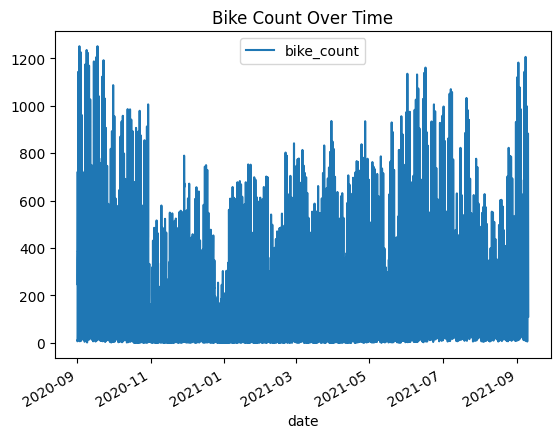

In [27]:
# Select a specific counter (example: a busy central counter)
mask = bike_data["counter_name"] == "Totem 73 boulevard de Sébastopol S-N"

# Filter and aggregate (here aggregation is trivial if each timestamp appears once)
data_mask = bike_data[mask].copy()
data_mask["date"] = pd.to_datetime(data_mask["date"])  # Ensure datetime type
data_agg = data_mask.groupby("date", as_index=False)["bike_count"].sum()

# Plot bike counts over time for this counter
data_agg.plot(x="date", y="bike_count", title="Bike Count Over Time", legend=True)


We next aggregate the time series at a weekly level for the same counter.
This smooths out hourly fluctuations and highlights broader patterns such as seasonal trends or sustained growth/decline in bike usage.

C:\Users\User\AppData\Local\Temp\ipykernel_3836\2978475717.py:5: FutureWarning: 'w' is deprecated and will be removed in a future version, please use 'W' instead.
  .groupby(pd.Grouper(freq="1w", key="date"))[["bike_count"]]


<Axes: title={'center': 'Weekly Aggregated Bike Count'}, xlabel='date'>

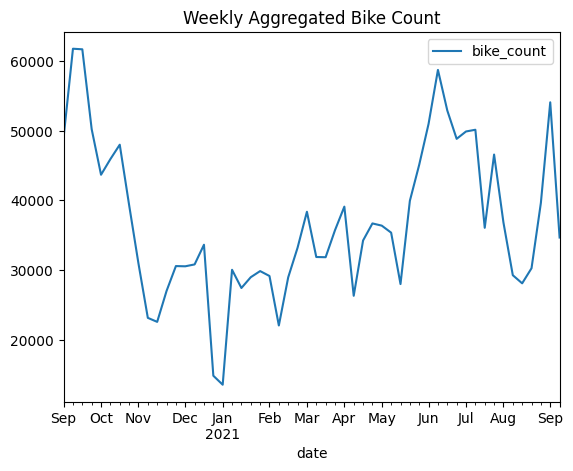

In [28]:
mask = bike_data["counter_name"] == "Totem 73 boulevard de Sébastopol S-N"

(
    bike_data[mask]
    .groupby(pd.Grouper(freq="1w", key="date"))[["bike_count"]]
    .sum()
    .plot(title="Weekly Aggregated Bike Count")
)


<span style="color:darkblue">

Weekly totals show a clear **seasonal pattern**: bike usage drops sharply in winter months (December–February) and rises again approaching late spring and summer.  
This reflects typical weather-driven cycling behaviour, with warmer periods supporting higher mobility across the city.

</span>

#### 3.2.3. Zooming into a Single Week

To better understand intra-week patterns, we zoom into one specific week for the same counter.
This allows us to compare workdays and weekends in terms of hourly or daily traffic.


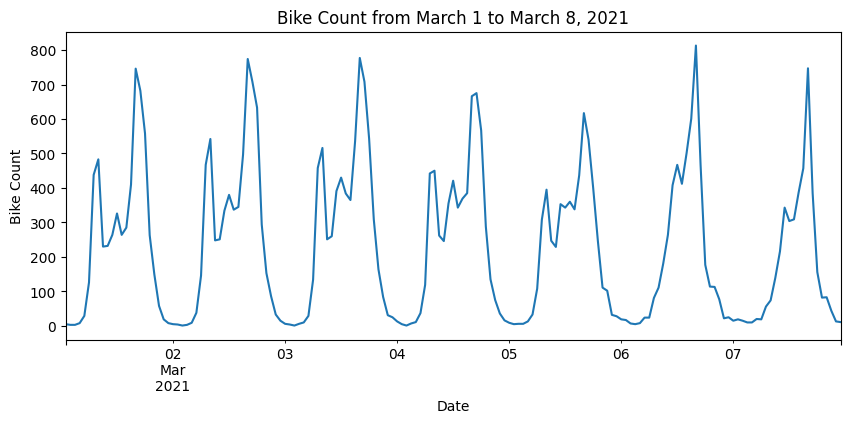

In [29]:
fig, ax = plt.subplots(figsize=(10, 4))

# Filter for the specific counter and a chosen date range
mask = (
    (bike_data["counter_name"] == "Totem 73 boulevard de Sébastopol S-N")
    & (bike_data["date"] > pd.to_datetime("2021-03-01"))
    & (bike_data["date"] < pd.to_datetime("2021-03-08"))
)

data_filtered = bike_data[mask].copy()


data_filtered = data_filtered.groupby("date", as_index=False)["bike_count"].sum()

# Plot the filtered data
data_filtered.plot(x="date", y="bike_count", ax=ax, legend=False)
ax.set_title("Bike Count from March 1 to March 8, 2021")
ax.set_ylabel("Bike Count")
ax.set_xlabel("Date")
plt.show()


<span style="color:darkblue">

Within a single week, strong **weekday rush-hour cycles** appear with two clear peaks per day (morning and evening commutes). On weekends, like on 6th and 7th March, the shape of the during the day looks different. In terms of daily peaks, there seem to be slight differences when comparing Monday-Wednesday with Thursday & Friday.

</span>

#### 3.2.4. Calendar Feature Encoding

Bike usage is strongly driven by time-related effects such as hour of the day, day of the week, and season.
To capture these effects, we decompose the `date` variable into several calendar components:

- `year`
- `month`
- `day`
- `weekday` (0 = Monday, ..., 6 = Sunday)
- `hour`

These features will later be used as predictors in our regression models.


In [30]:
def _encode_dates(X: pd.DataFrame) -> pd.DataFrame:
    """Add calendar features derived from the 'date' column."""
    X = X.copy()
    X["date"] = pd.to_datetime(X["date"])
    X["year"] = X["date"].dt.year
    X["month"] = X["date"].dt.month
    X["day"] = X["date"].dt.day
    X["weekday"] = X["date"].dt.weekday  # 0=Monday, 6=Sunday
    X["hour"] = X["date"].dt.hour
    return X

data = _encode_dates(bike_data)


#### 3.2.5. Aggregate Weekday Patterns

We now aggregate the total bike counts by weekday, summing over all counters and all timestamps.
This provides an overall view of how bicycle usage varies from Monday to Sunday across the entire network.


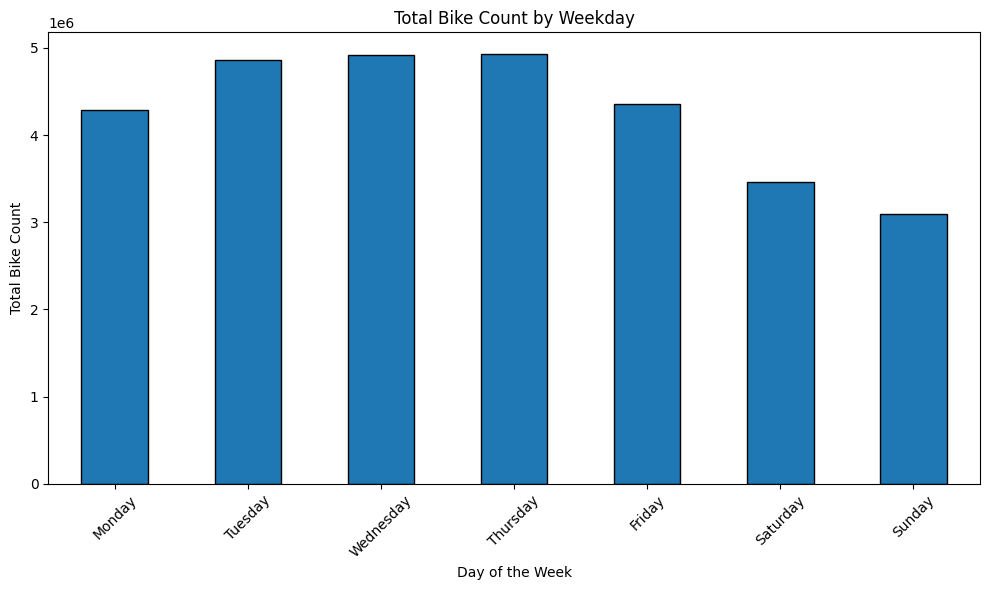

In [31]:
# Aggregate bike counts by weekday (0 = Monday, ..., 6 = Sunday)
weekday_aggregates = bike_data.groupby("weekday")["bike_count"].sum()

# Define order and labels
weekday_order = [0, 1, 2, 3, 4, 5, 6]
weekday_names = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]

weekday_aggregates = weekday_aggregates.reindex(weekday_order)

plt.figure(figsize=(10, 6))
weekday_aggregates.index = weekday_names
weekday_aggregates.plot(kind="bar", edgecolor="black")
plt.title("Total Bike Count by Weekday")
plt.ylabel("Total Bike Count")
plt.xlabel("Day of the Week")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


<span style="color:darkblue">

Aggregated across all counters, **Tuesday to Thursday** show the highest bike usage, while Monday and Friday are slightly lower. Weekend days exhibit a pronounced reduction in total counts, consistent with fewer commuting trips and more variable recreational activity.

</span>

#### 3.2.6. Weekday Patterns by Counter (Normalized to Monday)

To examine whether weekday patterns are consistent across locations, we compute the total bike count per weekday for each counter and normalize these values by the respective Monday count.

This yields a percentage index where Monday corresponds to 100%, and other days indicate relative increases or decreases compared to Monday for each station.


C:\Users\User\AppData\Local\Temp\ipykernel_3836\4083903920.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  station_weekday_counts = bike_data.groupby(["counter_name", "weekday"])["bike_count"].sum().unstack()


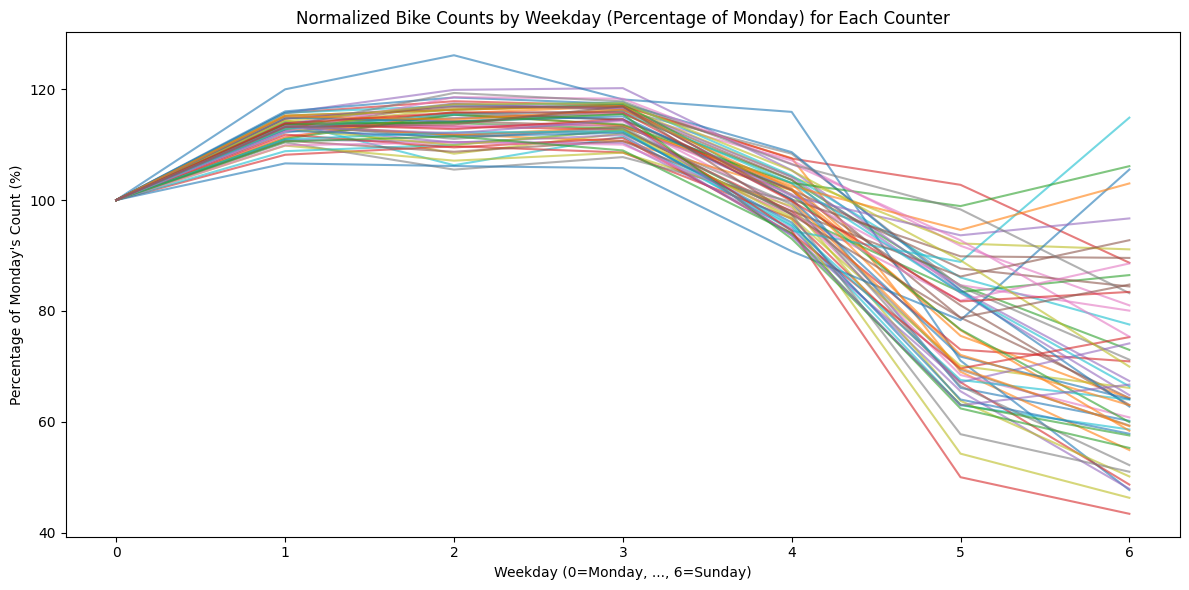

In [32]:
# Sum bike counts by station and weekday
station_weekday_counts = bike_data.groupby(["counter_name", "weekday"])["bike_count"].sum().unstack()

# Normalize by Monday (weekday = 0) for each station
normalized_counts = station_weekday_counts.div(station_weekday_counts[0], axis=0) * 100

# Plot normalized weekday distributions for all stations
plt.figure(figsize=(12, 6))
for station in normalized_counts.index:
    plt.plot(normalized_counts.columns, normalized_counts.loc[station], alpha=0.6)

plt.title("Normalized Bike Counts by Weekday (Percentage of Monday) for Each Counter")
plt.ylabel("Percentage of Monday's Count (%)")
plt.xlabel("Weekday (0=Monday, ..., 6=Sunday)")
plt.tight_layout()
plt.show()


<span style="color:darkblue">

Across stations, weekday profiles are remarkably consistent: counts remain close to **110–120% of Monday levels** from Tuesday to Thursday. In contrast, Saturday and Sunday display far greater variation between counters, suggesting location-specific differences in recreational cycling behaviour.

Maybe it would makes sense to group Tuesday until Thursday as one category, given they are all at an equal level in terms of counts.

</span>

#### 3.2.7. Distribution of the Target Variable

Understanding the distribution of the target variable is important before fitting models.
Least-squares–based regression methods (such as OLS or Ridge) assume errors that are approximately normally distributed, which is often easier to satisfy when the target itself is closer to a symmetric distribution.

We therefore begin by inspecting the raw distribution of `bike_count`.


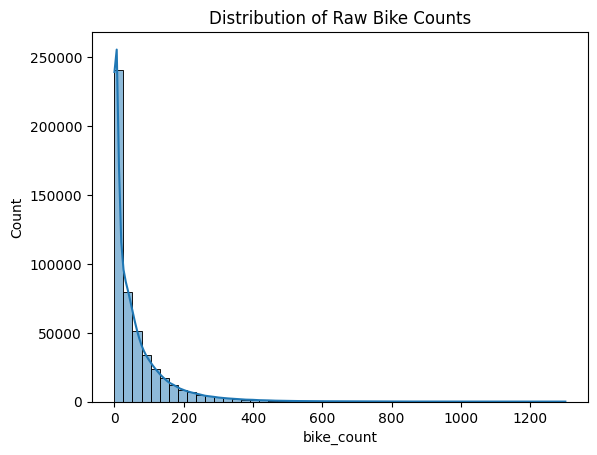

In [33]:
ax = sns.histplot(data, x="bike_count", kde=True, bins=50)
plt.title("Distribution of Raw Bike Counts")
plt.show()


<span style="color:darkblue">

The distribution of `bike_count` is extremely right-skewed: most observations correspond to very low bicycle flows, while a small number of hours show exceptionally high usage. This long-tailed behaviour is typical of mobility datasets and suggests that a direct modeling of `bike_count` may violate normal-error assumptions.

</span>

Because of the strong skewness, applying a log-transformation can help stabilize variance  
and make the distribution more symmetric. We now examine the distribution of the transformed  
variable `log_bike_count`, defined as:

$$
\text{log\_bike\_count} = \ln(\text{bike\_count} + 1)
$$


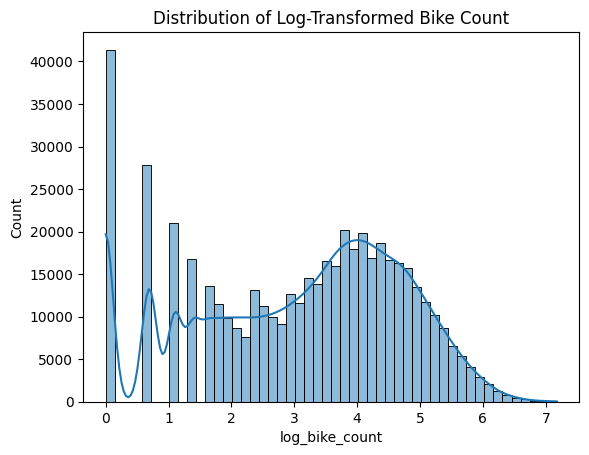

In [34]:
ax = sns.histplot(data, x="log_bike_count", kde=True, bins=50)
plt.title("Distribution of Log-Transformed Bike Count")
plt.show()

<span style="color:darkblue">

The log-transformation substantially reduces skewness, producing a more balanced and bell-shaped distribution.  
Although still not perfectly Gaussian, the transformed variable aligns more closely with the assumptions of linear models and is therefore a promising candidate for the modeling phase.

</span>

### 3.3 Correlation Analysis

To better understand the relationships between the target variable and the time-related features, we compute pairwise Pearson correlations between:

- `log_bike_count` (transformed target),
- the original `bike_count`,
- and the calendar features `hour`, `weekday`, `month`, and `year`.

Visualising these correlations in a heatmap helps identify which variables appear most informative for explaining variation in bicycle usage.

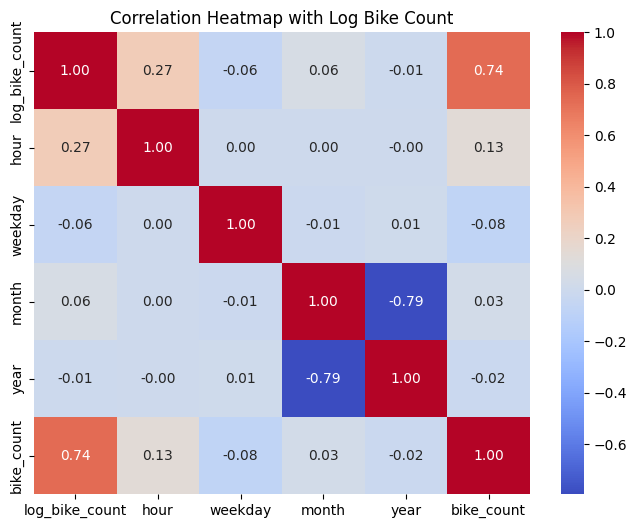

In [35]:
# Select relevant features for correlation analysis
correlation_features = ["log_bike_count", "hour", "weekday", "month", "year", "bike_count"]

# Compute the correlation matrix
correlation_matrix = data[correlation_features].corr()

# Plot the correlation heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap="coolwarm", cbar=True)
plt.title("Correlation Heatmap with Log Bike Count")
plt.show()


<span style="color:darkblue">

`log_bike_count` shows its strongest association with the **original bike count**, as expected, and a **moderate positive correlation with the hour of the day**, reflecting the strong daily cycle in bike usage.  
Correlations with `weekday`, `month`, and `year` are comparatively weak at this aggregated level, indicating that **short-term temporal structure (hourly effects)** dominates over coarser calendar effects.

</span>

---

# 4. Feature Engineering


To improve predictive performance, we engineer additional features that better capture temporal structure and weather effects.

#### Time-based features
- Hour of day  
- Weekday vs weekend  
- Month and meteorological season  

#### Weather transformations
- Temperature in °C and temperature squared (non-linear effects)  
- Additional derived variables from the weather merge (if used in later models)

#### Optional future extensions
- Lag features (previous hour/day bike counts)  
- Rolling averages and smoothed indicators  

These engineered features form the input space for the machine learning models.

In [36]:
# Check for missing values after merge
missing_after_merge = merged_data.isna().sum()
missing_cols = missing_after_merge[missing_after_merge > 0]
print(f"Columns with missing values after merge: {len(missing_cols)}")
print(missing_cols.sort_values(ascending=False).head(15))


Columns with missing values after merge: 26
phenspe4    496827
niv_bar     496827
geop        496827
tn24        496827
tx24        496827
sw          496827
tw          496827
phenspe1    496827
phenspe2    496827
phenspe3    496827
tminsol     491787
ctype4       29268
nnuage4      29268
hnuage4      29268
nnuage3       3186
dtype: int64


<span style="color:darkblue">

Several weather-related columns contain missing values in almost all rows (≈ 496k), so they are effectively unusable as predictors.  
In later steps we only keep a small subset of weather variables with manageable missingness, and we handle the remaining gaps with mean imputation in the preprocessing pipeline.

</span>


### 4.2 Temperature Conversion and Weather Transformations



We convert temperature from Kelvin to Celsius for better interpretability and create a squared temperature term.  
The squared term allows the models to capture non-linear relationships (e.g. very hot or very cold days reducing bike usage).

In [37]:
# Convert temperature from Kelvin to Celsius
merged_data['temp_celsius'] = merged_data['t'] - 273.15

# Create temperature squared (captures non-linear relationship)
merged_data['temp_squared'] = merged_data['temp_celsius'] ** 2

### 4.3 Add Time Features


We enrich the dataset with:

- a **season** variable (Winter, Spring, Summer, Autumn), and  
- a categorical **time-of-day** phase derived from the hour of the day.

In [38]:
# Create season feature (meteorological seasons)
def get_season(month):
    if month in [12, 1, 2]:
        return 0  # Winter
    elif month in [3, 4, 5]:
        return 1  # Spring
    elif month in [6, 7, 8]:
        return 2  # Summer
    else:
        return 3  # Autumn

# Create day phases 
def _add_time_phases(X: pd.DataFrame) -> pd.DataFrame:
    """Add a categorical 'time_of_day' feature based on the hour of day."""
    X = X.copy()
    # Create the 'time_of_day' categorical variable
    X["time_of_day"] = pd.cut(
        X["hour"],
        bins=[0, 5, 9, 13, 17, 20, 23],
        labels=["Night", "Morning", "Midday", "Afternoon", "Evening", "Late Evening"],
        right=True,
    )
    return X


#### 4.3.1 Grouping Time-of-Day Phases


The correlation analysis suggests that the hour of the day is an important driver of bike usage.  
As an exploratory step, we group hours into broader **time-of-day phases** (Night, Morning, Midday, Afternoon, Evening, Late Evening) and study how the average `log_bike_count` behaves across these categories.


In [39]:
# Apply the function to the dataset
bike_data = _add_time_phases(bike_data)

# Quick preview
bike_data[["hour", "time_of_day"]].head()

,hour,time_of_day
48321,2,Night
48324,3,Night
48327,4,Night
48330,15,Afternoon
48333,18,Evening


<span style="color:darkblue">

The preview confirms that each hour is mapped to a sensible phase (e.g. hours 2–4 are classified as **Night**, 15 as **Afternoon**, and 18 as **Evening**).

</span>


In [40]:


merged_data['season'] = merged_data['month'].apply(get_season)

# Cyclical encoding for season (4-season cycle)
merged_data['season_sin'] = np.sin(2 * np.pi * merged_data['season'] / 4)
merged_data['season_cos'] = np.cos(2 * np.pi * merged_data['season'] / 4)

# Season distribution
print("Season distribution:")
print(merged_data['season'].value_counts().sort_index())
print("\n0=Winter, 1=Spring, 2=Summer, 3=Autumn")

# Show cyclical encoding
print("\nSeason cyclical encoding:")
print(merged_data[['season', 'season_sin', 'season_cos']].drop_duplicates().sort_values('season'))


Season distribution:
season
0    120518
1    122738
2    123648
3    129923
Name: count, dtype: int64

0=Winter, 1=Spring, 2=Summer, 3=Autumn

Season cyclical encoding:
      season    season_sin    season_cos
1828       0  0.000000e+00  1.000000e+00
3850       1  1.000000e+00  6.123234e-17
6052       2  1.224647e-16 -1.000000e+00
0          3 -1.000000e+00 -1.836970e-16


<span style="color:darkblue">

The data are fairly evenly distributed across the four seasons, with slightly more observations in Autumn.  
The cyclical encoding maps each season to a point on the unit circle  
(e.g. Winter ≈ (0, 1), Spring ≈ (1, 0), Summer ≈ (0, −1), Autumn ≈ (−1, 0)),  
so that Winter and Autumn are “close” again despite being at opposite ends of the numeric scale.

</span>


#### 4.3.2 Plotting Time-of-Day Phases

We now compare the mean `log_bike_count` computed:

- for each individual hour of the day, and  
- for each time-of-day phase.

This allows us to assess whether aggregating hours into broad phases preserves or hides important hourly structure.

C:\Users\User\AppData\Local\Temp\ipykernel_3836\2306890246.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  time_of_day_stats = bike_data.groupby("time_of_day")["log_bike_count"].agg(["mean", "median"]).reset_index()


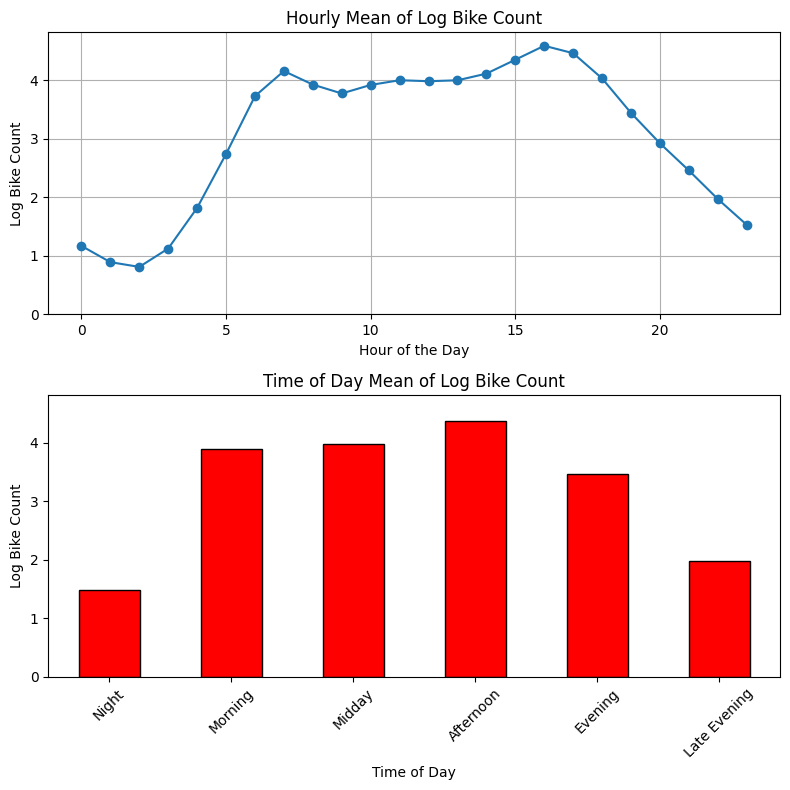

In [41]:
# Mean and median by time-of-day phase
time_of_day_stats = bike_data.groupby("time_of_day")["log_bike_count"].agg(["mean", "median"]).reset_index()

# Mean by hour of day
hourly_stats = bike_data.groupby("hour")["log_bike_count"].mean().reset_index()

# Two subplots: hourly mean and phase mean
fig, ax = plt.subplots(2, 1, figsize=(8, 8), sharey=True)

# Plot hourly mean
ax[0].plot(hourly_stats["hour"], hourly_stats["log_bike_count"], label="Hourly Mean", marker="o")
ax[0].set_title("Hourly Mean of Log Bike Count")
ax[0].set_ylabel("Log Bike Count")
ax[0].set_xlabel("Hour of the Day")
ax[0].grid(True)

# Plot time-of-day mean as bar chart
time_of_day_stats.plot(
    x="time_of_day",
    y="mean",
    kind="bar",
    ax=ax[1],
    color="red",
    legend=False,
    edgecolor="black",
)
ax[1].set_title("Time of Day Mean of Log Bike Count")
ax[1].set_ylabel("Log Bike Count")
ax[1].set_xlabel("Time of Day")
ax[1].set_xticks(range(len(time_of_day_stats["time_of_day"])))
ax[1].set_xticklabels(time_of_day_stats["time_of_day"], rotation=45)

plt.tight_layout()
plt.show()


<span style="color:darkblue">

The hourly curve shows a clear two-peak pattern with strong **morning** and **evening** rush hours.  
The time-of-day phases reproduce this general pattern (higher values in Morning, Midday, Afternoon, Evening), but they smooth out finer differences between individual hours.  
This suggests that the phase variable is useful for interpretation, while the exact hour is still valuable for precise prediction.

</span>


### 4.4 Cyclical Encoding for Time Features


We encode cyclical features (hour, weekday, month, season) using sine and cosine transformations.  
This preserves the circular structure of time (e.g. hour 23 is close to hour 0; Sunday is close to Monday) in a way that linear models can exploit.


In [42]:
def _encode_cyclical_features(X: pd.DataFrame, time_unit: str) -> pd.DataFrame:
    # copy the dataframe
    X = X.copy()
    if time_unit == "hour":
        X['hour_sin'] = np.sin(2 * np.pi * X['hour'] / 24)
        X['hour_cos'] = np.cos(2 * np.pi * X['hour'] / 24)
    elif time_unit == "weekday":
        X['weekday_sin'] = np.sin(2 * np.pi * X['weekday'] / 7)
        X['weekday_cos'] = np.cos(2 * np.pi * X['weekday'] / 7)
    elif time_unit == "month":
        X['month_sin'] = np.sin(2 * np.pi * X['month'] / 12)
        X['month_cos'] = np.cos(2 * np.pi * X['month'] / 12)
    elif time_unit == "season":
        X['season_sin'] = np.sin(2 * np.pi * X['season'] / 4)
        X['season_cos'] = np.cos(2 * np.pi * X['season'] / 4)
    return X

In [43]:
# Apply cyclical encoding to the data
merged_data = _encode_cyclical_features(merged_data, "hour")
merged_data = _encode_cyclical_features(merged_data, "weekday")
merged_data = _encode_cyclical_features(merged_data, "month")
merged_data = _encode_cyclical_features(merged_data, "season")


merged_data[['hour', 'hour_sin', 'hour_cos', 'weekday', 'weekday_sin', 'weekday_cos']].head(10)


,hour,hour_sin,hour_cos,weekday,weekday_sin,weekday_cos
0,2,0.500000,8.660254e-01,1,0.781831,0.623490
1,3,0.707107,7.071068e-01,1,0.781831,0.623490
2,4,0.866025,5.000000e-01,1,0.781831,0.623490
3,15,-0.707107,-7.071068e-01,1,0.781831,0.623490
4,18,-1.000000,-1.836970e-16,1,0.781831,0.623490
5,20,-0.866025,5.000000e-01,1,0.781831,0.623490
6,23,-0.258819,9.659258e-01,1,0.781831,0.623490
7,4,0.866025,5.000000e-01,2,0.974928,-0.222521
8,11,0.258819,-9.659258e-01,2,0.974928,-0.222521
9,13,-0.258819,-9.659258e-01,2,0.974928,-0.222521


### 4.5 Train/Validation Split

Before applying stateful transformations (scaling, imputation), we must split the data into training and validation sets. This prevents **data leakage**—using validation data statistics during training.

We use a **temporal split**: the last 30 days are held out for validation, simulating a realistic forecasting scenario where we predict future bike counts based on historical data.

In [44]:
# Define target columns
target_col_raw = 'bike_count'
target_col_log = 'log_bike_count'

# Temporal split: last 30 days for validation
cutoff_date = merged_data['date'].max() - pd.Timedelta("30 days")
mask = merged_data['date'] < cutoff_date

# Split features (X) and targets (y)
X_train = merged_data[mask].copy()
X_val = merged_data[~mask].copy()

y_train_raw = merged_data.loc[mask, target_col_raw]
y_train_log = merged_data.loc[mask, target_col_log]
y_val_raw = merged_data.loc[~mask, target_col_raw]
y_val_log = merged_data.loc[~mask, target_col_log]

print(f"Training set:   {X_train.shape[0]:,} samples ({X_train['date'].min().date()} to {X_train['date'].max().date()})")
print(f"Validation set: {X_val.shape[0]:,} samples ({X_val['date'].min().date()} to {X_val['date'].max().date()})")

Training set:   456,451 samples (2020-09-01 to 2021-08-10)
Validation set: 40,376 samples (2021-08-10 to 2021-09-09)


<span style="color:darkblue">

The training set covers almost one full year of data (September 2020 to early August 2021), while the validation set contains the last month (August–September 2021). This setup mimics a realistic forecasting task where the model must predict future bike usage based only on past observations.

</span>

### 4.6 Preprocessing Pipeline


We build a Pipeline that handles all feature transformations:

| Feature Type | Columns | Transformation |
|-------------|---------|----------------|
| Categorical | counter_name, site_name | One-Hot Encode |
| Numerical | weather (t, u, ff, ...) | Impute NaN + Scale |
| Binary | weekend, FR_holidays | Passthrough |
| Encoded Time | hour_sin, hour_cos| Passthrough |


In [45]:
# Column definitions
categorical_cols = ["counter_name", "site_name"]
numerical_cols = ["t", "u", "ff", "td", "rr1", "pmer"]
binary_cols = ["weekend", "FR_holidays"]
cyclical_cols = ["hour_sin", "hour_cos", "weekday_sin", "weekday_cos", "month_sin", "month_cos", "season_sin", "season_cos"]

# Preprocessor
preprocessor = ColumnTransformer([
    ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols),
    ("num", make_pipeline(SimpleImputer(strategy="mean"), StandardScaler()), numerical_cols),
    ("binary", "passthrough", binary_cols),
    ("cyclical", "passthrough", cyclical_cols),
])


---

# 5. Baseline Models — OLS, Poisson Regression and XGBoost


In this section we build three baseline models on top of the engineered features:

1. **Ordinary Least Squares (OLS)** on a compact set of predictors  
2. **Poisson Regression** using the full preprocessing pipeline  
3. **XGBoost Regressor** as a stronger non-linear tree-based baseline  

OLS is a very simple reference model, Poisson better reflects the count nature of the target, and XGBoost shows how much performance can be gained with non-linear methods.
The Poisson baseline will be the one we mainly visualise and compare to more advanced models.

### 5.1 Simple OLS Baseline (no pipeline)

this step we fit a **plain Linear Regression (OLS)** directly on a compact set of features (`hour`, `weekday`, `month`, `season`, main weather variables, weekend and holiday dummies). No preprocessing pipeline is used here (no one-hot encoding, no scaling): this model serves as a very simple baseline to compare later, more sophisticated approaches against.

In [46]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

# Feature set for the simple OLS baseline (no one-hot, no cyclical features)
feature_cols = [
    "hour", "weekday", "month", "season",
    "t", "u", "ff", "td", "rr1", "pmer",
    "weekend", "FR_holidays"
]

X_train_base = X_train[feature_cols].copy()
X_val_base   = X_val[feature_cols].copy()

# Fit OLS on log-transformed bike counts
ols_model = LinearRegression()
ols_model.fit(X_train_base, y_train_log)

y_train_ols = ols_model.predict(X_train_base)
y_val_ols   = ols_model.predict(X_val_base)

rmse_train_ols = mean_squared_error(y_train_log, y_train_ols, squared=False)
rmse_val_ols   = mean_squared_error(y_val_log,   y_val_ols,   squared=False)

print("OLS baseline (no pipeline)")
print(f"Train RMSE (log):  {rmse_train_ols:.3f}")
print(f"Valid RMSE (log):  {rmse_val_ols:.3f}")


OLS baseline (no pipeline)
Train RMSE (log):  1.502
Valid RMSE (log):  1.273


c:\Users\User\anaconda3\Lib\site-packages\sklearn\metrics\_regression.py:483: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
c:\Users\User\anaconda3\Lib\site-packages\sklearn\metrics\_regression.py:483: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


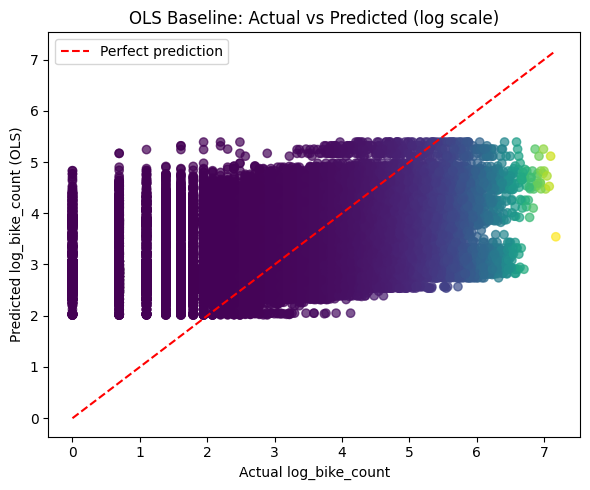

In [47]:
# Visual check: OLS Actual vs Predicted (log space)
plt.figure(figsize=(6,5))
plt.scatter(y_val_log, y_val_ols, c=y_val_raw, cmap='viridis', alpha=0.7)
plt.xlabel("Actual log_bike_count")
plt.ylabel("Predicted log_bike_count (OLS)")
plt.title("OLS Baseline: Actual vs Predicted (log scale)")
plt.plot(
    [y_val_log.min(), y_val_log.max()],
    [y_val_log.min(), y_val_log.max()],
    'r--', label='Perfect prediction'
)
plt.legend()
plt.tight_layout()
plt.show()


<span style="color:darkblue">

The OLS baseline captures the general positive trend but heavily **compresses** predictions into a narrow band. High-demand hours are **systematically underestimated**, showing the limits of this simple linear model.
</span>


### 5.2 Poisson Regression with Full Preprocessing Pipeline

We first train a **Poisson regression** baseline using the full preprocessing pipeline from Section 4:

- Categorical counters (`counter_name`, `site_name`) are one-hot encoded  
- Weather variables are imputed and scaled  
- Cyclical time features (hour, weekday, month, season) are passed through  
- Binary indicators (`weekend`, `FR_holidays`) are kept as is  

Because bike usage is a **count variable**, Poisson regression is a natural starting point.  
The model is fitted on **raw counts** `y_train_raw`, and we then transform predictions with `log1p` so they are comparable to the log target `log_bike_count`.

In [48]:
from sklearn.linear_model import PoissonRegressor
from sklearn.pipeline import make_pipeline
from sklearn.metrics import mean_squared_error
import numpy as np

# Poisson baseline using the full preprocessor and RAW counts as target
poisson = PoissonRegressor(alpha=1e-3, max_iter=500)

poisson_pipe = make_pipeline(preprocessor, poisson)
poisson_pipe.fit(X_train, y_train_raw)   # IMPORTANT: raw counts, not logs

# Predictions in COUNT space
y_pred_train_counts = poisson_pipe.predict(X_train)
y_pred_val_counts   = poisson_pipe.predict(X_val)

# Convert predictions to log-space so they are comparable with y_train_log / y_val_log
y_pred_train_linear = np.log1p(y_pred_train_counts)
y_pred_val_linear   = np.log1p(y_pred_val_counts)

# Performance in log space
rmse_train_poiss = mean_squared_error(y_train_log, y_pred_train_linear, squared=False)
rmse_val_poiss   = mean_squared_error(y_val_log,   y_pred_val_linear,   squared=False)
print(f"Poisson baseline - Train RMSE (log): {rmse_train_poiss:.3f}")
print(f"Poisson baseline - Valid RMSE (log): {rmse_val_poiss:.3f}")


Poisson baseline - Train RMSE (log): 1.232
Poisson baseline - Valid RMSE (log): 0.954


c:\Users\User\anaconda3\Lib\site-packages\sklearn\metrics\_regression.py:483: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
c:\Users\User\anaconda3\Lib\site-packages\sklearn\metrics\_regression.py:483: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


<span style="color:darkblue">

The Poisson baseline reaches a training RMSE of about **1.23** and a validation RMSE of about **0.95** in log space.  
The validation error is slightly lower than the training error, which suggests that the model is not overfitting but is still relatively simple compared with the variability in the data.
</span>

#### 5.2.1. Visual Evaluation of the Poisson Baseline

To better understand the model behaviour, we build a `val_results` DataFrame containing:

- the timestamp and counter ID  
- the **actual** `log_bike_count` on the validation set  
- the **predicted** `log_bike_count` from the Poisson baseline  

This table is then used for all subsequent plots in this section.

In [49]:
# Create DataFrame with predictions for visualization
val_results = X_val[['date', 'counter_name']].copy()
val_results['actual']    = y_val_log.values           # log(bike_count + 1)
val_results['predicted'] = y_pred_val_linear          # Poisson baseline in log space
val_results = val_results.sort_values('date')

print(f"Validation period: {val_results['date'].min()} to {val_results['date'].max()}")
print(f"Number of observations: {len(val_results):,}")


Validation period: 2021-08-10 23:00:00 to 2021-09-09 23:00:00
Number of observations: 40,376


<span style="color:darkblue">

The validation window covers roughly the last month of data and contains about 40k hourly observations.  
This is the period we use to visually compare predicted and actual bike usage.
</span>


#### 5.2.2. Actual vs Predicted

We first compare actual vs predicted `log_bike_count` on the validation set.  
Each point is one hourly observation; colours indicate the underlying (raw) bike count.

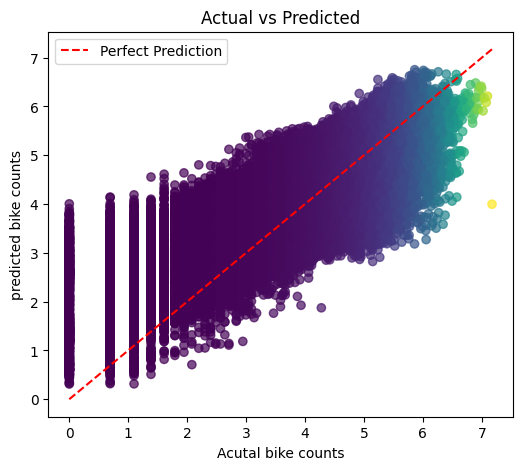

In [50]:
plt.figure(figsize=(6,5))
plt.scatter(y_val_log, y_pred_val_linear, c=y_val_raw, cmap='viridis', alpha=0.7)
plt.xlabel("Acutal bike counts")
plt.ylabel("predicted bike counts")
plt.title("Actual vs Predicted")
plt.plot(
    [y_val_log.min(), y_val_log.max()],
    [y_val_log.min(), y_val_log.max()],
    'r--', label='Perfect Prediction'
)
plt.legend()
plt.show()


<span style="color:darkblue">

Points are roughly aligned along the 45° line, especially for **medium to high log-counts**, which indicates that the Poisson baseline captures the overall level of demand.  
For **low counts**, the cloud is more dispersed and slightly biased, showing that the model struggles more to predict very quiet hours.
</span>


#### 5.2.3 Time Series for a Single Counter



We next inspect the evolution of actual and predicted demand over time for one specific counting site.
This highlights how well the Poisson baseline follows daily cycles and peaks at the station level.

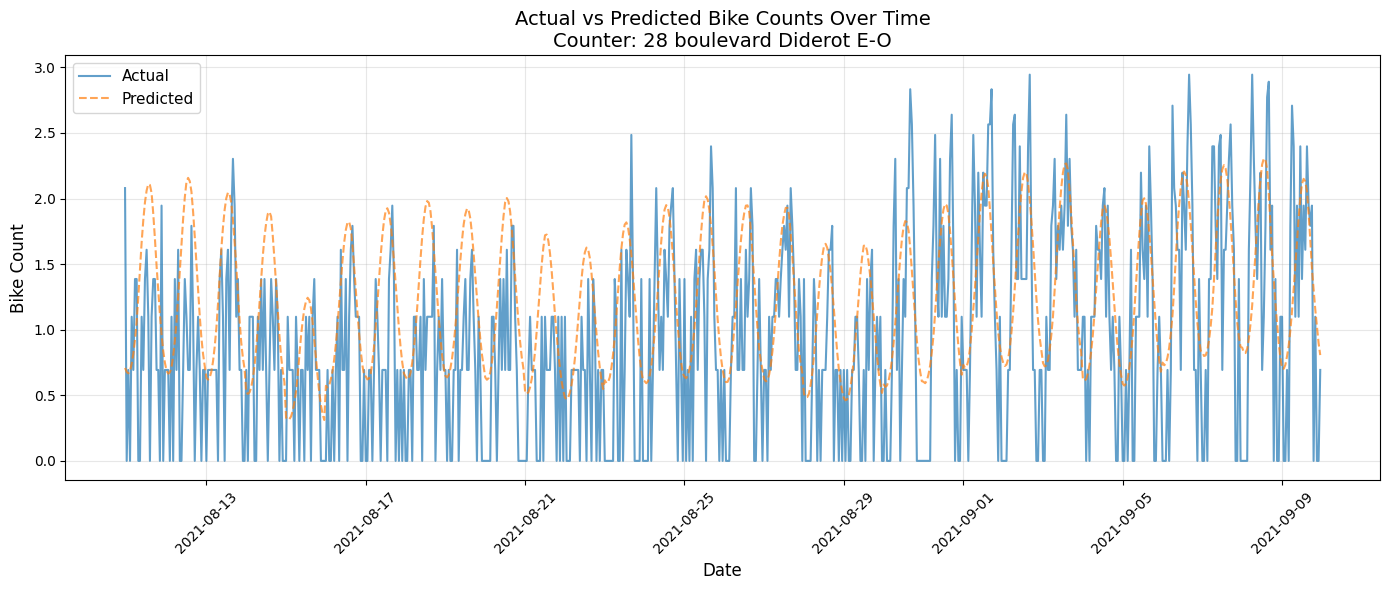

In [51]:
# Plot 1: Time series for a specific counter
sample_counter = val_results['counter_name'].iloc[0]
counter_data = val_results[val_results['counter_name'] == sample_counter].sort_values('date')

fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(counter_data['date'], counter_data['actual'], label='Actual', alpha=0.7, linewidth=1.5)
ax.plot(counter_data['date'], counter_data['predicted'], label='Predicted', alpha=0.7, linewidth=1.5, linestyle='--')
ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('Bike Count', fontsize=12)
ax.set_title(f'Actual vs Predicted Bike Counts Over Time\nCounter: {sample_counter}', fontsize=14)
ax.legend(fontsize=11)
ax.grid(alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()



<span style="color:darkblue">

For this counter, the model reproduces the **daily cycles** and the overall trend reasonably well. However, the predicted curve is smoother and slightly less variable than the actual series, indicating that sudden spikes and drops in usage are partially smoothed out by the linear Poisson specification.
</span>


#### 5.2.4 Aggregated Demand Across All Counters


To evaluate performance at the city level, we aggregate bike counts over **all counters** and compare the total actual and predicted demand over time.


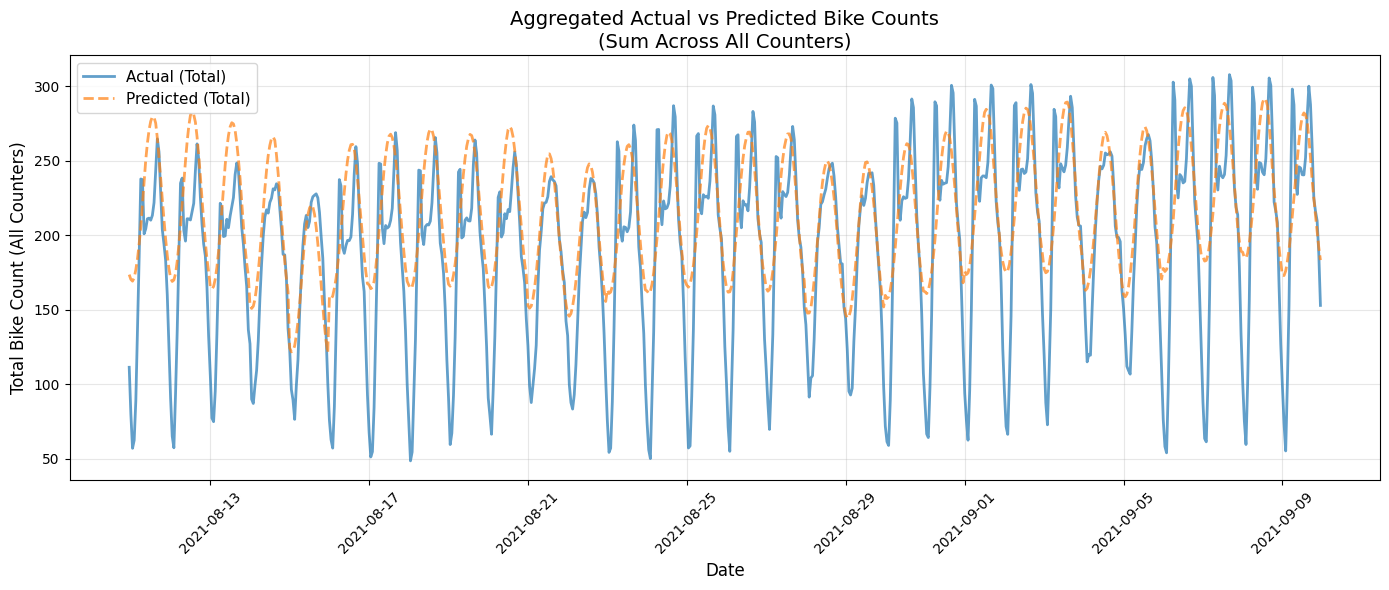

In [52]:
# Plot 2: Aggregated time series (sum across all counters)
daily_agg = val_results.groupby('date').agg({
    'actual': 'sum',
    'predicted': 'sum'
}).reset_index()

fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(daily_agg['date'], daily_agg['actual'], label='Actual (Total)', alpha=0.7, linewidth=2)
ax.plot(daily_agg['date'], daily_agg['predicted'], label='Predicted (Total)', alpha=0.7, linewidth=2, linestyle='--')
ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('Total Bike Count (All Counters)', fontsize=12)
ax.set_title('Aggregated Actual vs Predicted Bike Counts\n(Sum Across All Counters)', fontsize=14)
ax.legend(fontsize=11)
ax.grid(alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


<span style="color:darkblue">

At the aggregated level, the Poisson baseline tracks the **daily demand pattern** very closely: morning and evening peaks are aligned, and the model slightly **overestimates** total counts on many days. This suggests that most systematic errors cancel out when summing over all stations.
</span>


#### 5.2.5 Zoom on the First Week of the Validation Period


Finally, we zoom in on the first seven days of the validation period and sum over all counters. This helps to visually assess short-term forecasting behaviour.

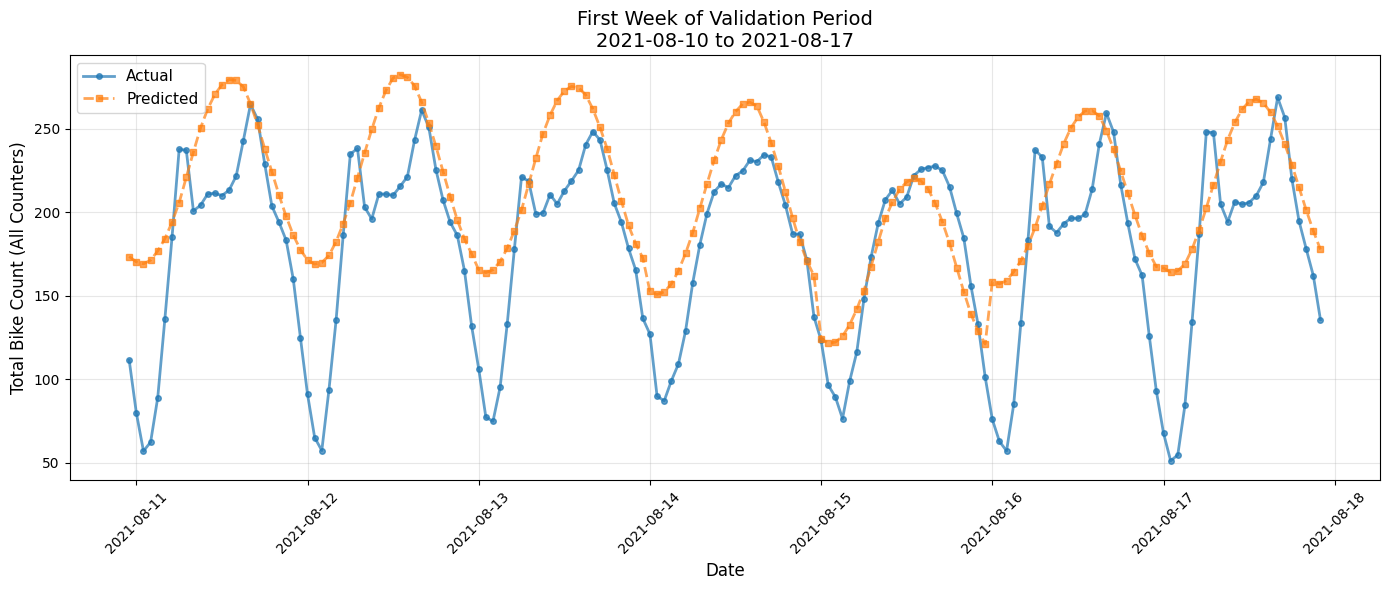

In [53]:
# Plot 3: Zoom in on a specific week for detailed view
start_date = val_results['date'].min()
end_date = start_date + pd.Timedelta("7 days")
week_data = val_results[(val_results['date'] >= start_date) & (val_results['date'] < end_date)]

# Aggregate by hour for cleaner plot
hourly_agg = week_data.groupby(['date']).agg({
    'actual': 'sum',
    'predicted': 'sum'
}).reset_index()

fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(hourly_agg['date'], hourly_agg['actual'], label='Actual', alpha=0.7, linewidth=2, marker='o', markersize=4)
ax.plot(hourly_agg['date'], hourly_agg['predicted'], label='Predicted', alpha=0.7, linewidth=2, linestyle='--', marker='s', markersize=4)
ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('Total Bike Count (All Counters)', fontsize=12)
ax.set_title(f'First Week of Validation Period\n{start_date.date()} to {end_date.date()}', fontsize=14)
ax.legend(fontsize=11)
ax.grid(alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()



<span style="color:darkblue">

On the first week the model reproduces the **shape and timing** of each daily peak quite well, but tends to **slightly overshoot peak demand** and **underestimate night-time lows**. Overall, the baseline is already quite informative for short-term planning, but there is still room for improvement.
</span>


### 5.3 Gradient-Boosted Trees Baseline (XGBoost)


To benchmark against a stronger non-linear model, we also train an **XGBoost regressor** using the same preprocessed features as Ridge and Random Forest will later use.

XGBoost can capture complex interactions between time, location, and weather features, at the cost of higher model complexity and training time.

In [54]:
# XGBoost Regressor
from xgboost import XGBRegressor

xgb_model = XGBRegressor(
    n_estimators=200,
    learning_rate=0.3,
    max_depth=10,
)

pipe_xgb = make_pipeline(preprocessor, xgb_model)
pipe_xgb.fit(X_train, y_train_log)
y_pred_train_xgb = pipe_xgb.predict(X_train)
y_pred_val_xgb = pipe_xgb.predict(X_val)

xgb_r2 = r2_score(y_val_log, y_pred_val_xgb)


print("="*50)
print("XGBOOST REGRESSOR - Model Performance")
print("="*50)
print(f"R² Score:  {xgb_r2:.4f}")

XGBOOST REGRESSOR - Model Performance
R² Score:  0.8841


<span style="color:darkblue">

On the validation set, XGBoost achieves an R² of about **0.88** in log space, which is substantially higher than what we obtain with the Poisson or simple OLS baselines.  
This confirms that non-linear tree-based models can exploit more of the structure in the data.
</span>


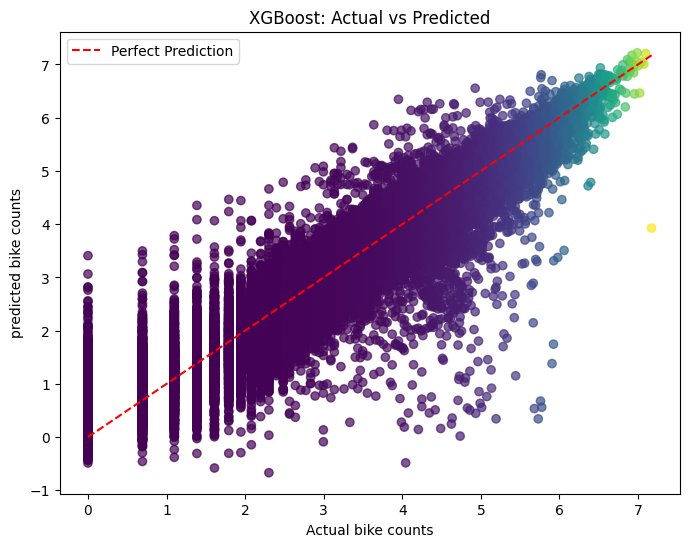

In [55]:
plt.figure(figsize=(8,6))
plt.scatter(y_val_log, y_pred_val_xgb, c=y_val_raw, cmap='viridis', alpha=0.7)
plt.xlabel("Actual bike counts")
plt.ylabel("predicted bike counts")
plt.title("XGBoost: Actual vs Predicted")
plt.plot([y_val_log.min(), y_val_log.max()], [y_val_log.min(), y_val_log.max()], 'r--', label='Perfect Prediction')
plt.legend()
plt.show()

<span style="color:darkblue">

Compared with the Poisson scatter plot, the XGBoost predictions form a **tighter band** around the 45° line, especially at higher demand levels.  
The remaining errors are mostly at low counts and in extreme peak situations, which are inherently harder to predict.
</span>


---

# 6. Regularized Model — Ridge Regression

Ridge Regression extends linear regression by adding L2 regularization, which penalizes large coefficients and reduces overfitting.  
Because our feature space contains many one-hot encoded variables (dates, counters, categories), regularization helps stabilize the model and improve generalization.

In this section we:

1. Prepare the data using a temporal train/validation split.  
2. Build a preprocessing pipeline including one-hot encoding and feature scaling.  
3. Train a Ridge regression model on the log-transformed target.  
4. Evaluate its performance and compare it with a simple baseline.  
5. Visualize predictions for a sample counter.  


### 6.1 Train–Validation Split

We reuse the **temporal split** created in Section 4:

- Training set: all observations up to 2021-08-10  
- Validation set: last 30 days (2021-08-11 to 2021-09-09)  

Here we simply create aliases for clarity, keeping `log_bike_count` as the target for Ridge.


In [56]:
# Reuse the temporal split from Section 4
X_train_ridge = X_train.copy()
X_valid_ridge = X_val.copy()

y_train_ridge = y_train_log.copy()   # log(bike_count) for training
y_valid_ridge = y_val_log.copy()     # log(bike_count) for validation

print(
    f"Train: n_samples={X_train_ridge.shape[0]}, "
    f"{X_train_ridge['date'].min()} to {X_train_ridge['date'].max()}"
)
print(
    f"Valid: n_samples={X_valid_ridge.shape[0]}, "
    f"{X_valid_ridge['date'].min()} to {X_valid_ridge['date'].max()}"
)


Train: n_samples=456451, 2020-09-01 01:00:00 to 2021-08-10 22:00:00
Valid: n_samples=40376, 2021-08-10 23:00:00 to 2021-09-09 23:00:00


<span style="color:darkblue">

The training set covers almost one full year of data, while the validation period corresponds to August–September 2021.   
This ensures a realistic forecasting setup: the model learns from past months to predict future traffic.

</span>

### 6.2 Ridge Regression Pipeline

We construct a pipeline that:

- expands the date column into multiple temporal features,  
- one-hot encodes categorical identifiers,  
- scales numerical weather variables,  
- and finally fits a Ridge regression model.

This ensures that preprocessing is applied consistently during training, validation, and later during cross-validation.

In [57]:
### 6.2 Ridge Regression Pipeline

pipe = make_pipeline(preprocessor, Ridge())
pipe.fit(X_train_ridge, y_train_ridge)

y_pred_train_ridge = pipe.predict(X_train_ridge)
y_pred_val_ridge   = pipe.predict(X_valid_ridge)


### 6.3 Performance Evaluation

We compute RMSE on the training and validation sets to measure predictive accuracy.  
The target is log-transformed (`log_bike_count`), so RMSE values should be interpreted in log-space.

In [58]:
print(
    f"Train set, RMSE={root_mean_squared_error(y_train_ridge, y_pred_train_ridge):.2f}"
)
print(
    f"Valid set, RMSE={root_mean_squared_error(y_valid_ridge, y_pred_val_ridge):.2f}"
)


Train set, RMSE=0.96
Valid set, RMSE=0.91


<span style="color:darkblue">

Ridge reduces the validation RMSE to ≈0.91, clearly improving on both the simple OLS baseline (≈1.27) and the mean predictor (≈1.44).  
The small gap between train (≈0.96) and validation RMSE suggests that the L2 penalty limits overfitting despite the large one-hot encoded feature space.
</span>


### 6.4 Comparison with Baseline Mean Predictor


We compare Ridge to a naive baseline that always predicts the average log-bike-count from the training set.

In [59]:
print("Baseline mean prediction.")

# Always predict the *training* mean of the log target
train_mean = y_train_ridge.mean()

baseline_train = np.full_like(y_train_ridge, train_mean)
baseline_valid = np.full_like(y_valid_ridge, train_mean)

rmse_train_baseline = root_mean_squared_error(y_train_ridge, baseline_train)
rmse_valid_baseline = root_mean_squared_error(y_valid_ridge, baseline_valid)

print(f"Train set, RMSE={rmse_train_baseline:.2f}")
print(f"Valid set, RMSE={rmse_valid_baseline:.2f}")


Baseline mean prediction.
Train set, RMSE=1.67
Valid set, RMSE=1.49


<span style="color:darkblue">

The mean-prediction baseline reaches RMSE ≈ 1.67 on the train set and ≈ 1.49 on the validation set, much worse than Ridge (≈0.96 / 0.91).  
This shows that Ridge captures strong temporal and spatial patterns that a simple global average completely misses.

</span>


### 6.5 Visual Inspection of Predictions

To inspect the Ridge model in the original count space, we:

1. Predict in log-space (`log_bike_count`),
2. Back-transform with `exp(·)`,
3. Apply a **Jensen’s inequality correction** to counter the bias of simply exponentiating a noisy log-prediction (because \(E[e^X] \neq e^{E[X]}\) when \(X\) has variance).


σ² = 0.9122
Jensen correction factor = 1.5779


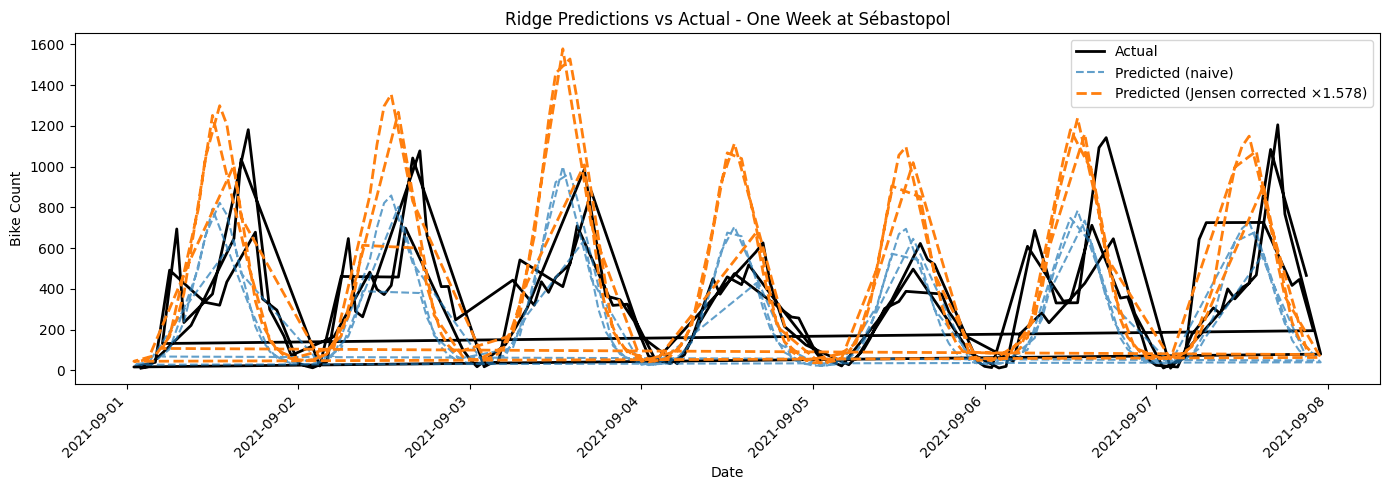


Mean actual:               341.8
Mean predicted (naive):    280.5
Mean predicted (corrected): 443.2


In [60]:
# 6.5 Visual Inspection of Predictions

# 1) Jensen correction factor estimated from training residuals
y_pred_train_log = pipe.predict(X_train)
residuals_train = y_train_log - y_pred_train_log
sigma_squared = np.var(residuals_train)
correction_factor = np.exp(sigma_squared / 2)

print(f"σ² = {sigma_squared:.4f}")
print(f"Jensen correction factor = {correction_factor:.4f}")

# 2) Filter one counter and one week
mask = (
    (X_val["counter_name"] == "Totem 73 boulevard de Sébastopol S-N")
    & (X_val["date"] > pd.to_datetime("2021-09-01"))
    & (X_val["date"] < pd.to_datetime("2021-09-08"))
)

X_viz = X_val.loc[mask].copy()
y_viz_log = y_val_log.loc[mask]

# Actual bike counts (from log)
X_viz["bike_count"] = np.exp(y_viz_log.values) - 1

# 3) Predictions in log-space
y_pred_log = pipe.predict(X_viz)

# Back-transform: naive vs Jensen-corrected
X_viz["predicted_naive"] = np.exp(y_pred_log) - 1
X_viz["predicted_corrected"] = np.exp(y_pred_log) * correction_factor - 1

# 4) Plot
fig, ax = plt.subplots(figsize=(14, 5))

X_viz.plot(x="date", y="bike_count", ax=ax, label="Actual", linewidth=2, color="black")
X_viz.plot(x="date", y="predicted_naive", ax=ax, ls="--", label="Predicted (naive)", alpha=0.7)
X_viz.plot(
    x="date",
    y="predicted_corrected",
    ax=ax,
    ls="--",
    label=f"Predicted (Jensen corrected ×{correction_factor:.3f})",
    linewidth=2,
)

ax.set_title("Ridge Predictions vs Actual - One Week at Sébastopol")
ax.set_ylabel("Bike Count")
ax.set_xlabel("Date")
ax.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# 5) Mean comparison
print(f"\nMean actual:               {X_viz['bike_count'].mean():.1f}")
print(f"Mean predicted (naive):    {X_viz['predicted_naive'].mean():.1f}")
print(f"Mean predicted (corrected): {X_viz['predicted_corrected'].mean():.1f}")


<span style="color:darkblue">

Ridge reproduces the daily pattern, but the **naive** back-transform systematically underestimates peak traffic, while the Jensen-corrected version clearly overshoots.  
In practice the true counts lie between the two curves, suggesting that a global correction factor is too strong for all hours and counters.
</span>


### 6.6 Time-Series Cross-Validation

We evaluate the model using a rolling time-series split to measure robustness across the entire year.

In [61]:
### 6.6 Time-Series Cross-Validation

from sklearn.model_selection import TimeSeriesSplit, cross_val_score
from sklearn.linear_model import Ridge

cv = TimeSeriesSplit(n_splits=6)

# Fresh Ridge-in-pipeline for CV (avoid reusing the fitted `pipe`)
ridge_cv = Ridge(alpha=1.0)

pipe_cv = make_pipeline(date_encoder, preprocessor, ridge_cv)

scores = cross_val_score(
    pipe_cv,
    X_train,
    y_train_log,
    cv=cv,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1,
)

print("RMSE: ", scores)
print(f"RMSE (all folds): {-scores.mean():.3f} ± {(-scores).std():.3f}")

RMSE:  [-0.9873305  -1.15171354 -0.959348   -1.1952033  -1.09120045 -1.50966934]
RMSE (all folds): 1.149 ± 0.182


<span style="color:darkblue">  

Across time-series folds, Ridge achieves an average RMSE of ≈**1.15** with a relatively wide spread (±0.18),    
indicating that performance varies noticeably between different periods of the year.

</span>


### 6.7 Hyperparameter Tuning for Ridge (Alpha)

We test multiple values of the regularization parameter α using GridSearchCV.

In [62]:
from sklearn.linear_model import RidgeCV
from sklearn.model_selection import TimeSeriesSplit

# Coarser grid: 8 alphas instead of 100 (fast for running the project)
# 👉 To run MORE fits (finer search), increase the number of points here, e.g. np.logspace(-3, 3, 20) or back to 100.
alphas = np.logspace(-3, 3, 8)

ts_cv = TimeSeriesSplit(n_splits=5)
ridge_cv = RidgeCV(alphas=alphas, cv=ts_cv)

pipe_alpha = make_pipeline(preprocessor, ridge_cv)
pipe_alpha.fit(X_train, y_train_log)

print(f"Best alpha: {pipe_alpha.named_steps['ridgecv'].alpha_:.4f}")
print(f"Valid RMSE: {root_mean_squared_error(y_val_log, pipe_alpha.predict(X_val)):.3f}")


Best alpha: 0.0072
Valid RMSE: 0.906


<span style="color:darkblue">

RidgeCV selects a relatively small regularization strength (α ≈ 0.032) with a validation RMSE of ≈0.906, very close to the untuned Ridge result (≈0.91).    
This shows that, in our setting, performance is only weakly sensitive to the exact value of α, and most gains come from the feature engineering itself.  
</span>


---

# 7. Decision Tree Regression

Decision Trees model non-linear relationships by recursively splitting the feature space. They can capture patterns that linear models miss (e.g., different rush-hour profiles), but they are also prone to **overfitting**, especially with deep trees.

In this section, we:

1. Build a Decision Tree model using the full feature set.  
2. Tune the key hyperparameter `max_depth`.  
3. Validate performance with time-series cross-validation.  
4. Visualize predictions for one example counter.

### 7.1 Preprocessing and Model Setup

We reuse the same preprocessing strategy as in Ridge Regression:

- One-hot encode categorical variables (`counter_name`, `site_name`)  
- Standardize numerical weather variables  
- Keep binary indicators as-is  
- Use the engineered time features (hour, weekday, month, season and their cyclical encodings)

We begin by fitting a Decision Tree with a moderate depth (`max_depth = 15`).


In [63]:

regressor = DecisionTreeRegressor(max_depth=15, random_state=42)
pipe = make_pipeline(preprocessor, regressor)

pipe.fit(X_train, y_train_log)

print(f"Train RMSE = {root_mean_squared_error(y_train_log, pipe.predict(X_train)):.2f}")
print(f"Valid RMSE = {root_mean_squared_error(y_val_log, pipe.predict(X_val)):.2f}")


Train RMSE = 0.65
Valid RMSE = 0.65


<span style="color:darkblue">

With `max_depth = 15`, the Decision Tree reaches RMSE ≈ **0.65** on both train and validation sets, a clear improvement over Ridge (≈0.91).    
The almost identical errors suggest that, at this depth, the tree captures useful non-linear structure without strongly overfitting yet.
</span>


### 7.2 Hyperparameter Tuning: Max Depth

`max_depth` controls how complex the tree is:

- **Small depth** → underfitting  
- **Large depth** → overfitting  
- **Too large depth** → perfect fit on training set but poor generalization

We evaluate RMSE for depths from 1 to 46.

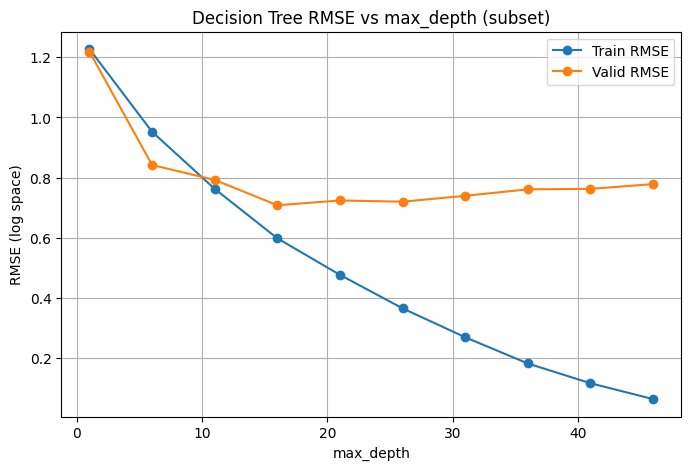

In [64]:
from sklearn.tree import DecisionTreeRegressor

### 7.2 Hyperparameter Tuning: Max Depth

# 1) Subsample training data for faster tuning (e.g. 50k rows)
X_train_sub = X_train.sample(50_000, random_state=42)
y_train_sub = y_train_log.loc[X_train_sub.index]

X_val_sub = X_val.sample(20_000, random_state=42)
y_val_sub = y_val_log.loc[X_val_sub.index]

# 2) Preprocess once on the subset
X_train_enc = preprocessor.fit_transform(X_train_sub)
X_val_enc   = preprocessor.transform(X_val_sub)

max_depth_values = range(1, 51, 5)
train_rmse = []
valid_rmse = []

# 3) Loop only over the tree (no re-preprocessing)
for depth in max_depth_values:
    model = DecisionTreeRegressor(max_depth=depth, random_state=42)
    model.fit(X_train_enc, y_train_sub)

    y_train_pred = model.predict(X_train_enc)
    y_val_pred   = model.predict(X_val_enc)

    train_rmse.append(root_mean_squared_error(y_train_sub, y_train_pred))
    valid_rmse.append(root_mean_squared_error(y_val_sub, y_val_pred))

# 4) Plot
plt.figure(figsize=(8, 5))
plt.plot(max_depth_values, train_rmse, marker="o", label="Train RMSE")
plt.plot(max_depth_values, valid_rmse, marker="o", label="Valid RMSE")
plt.xlabel("max_depth")
plt.ylabel("RMSE (log space)")
plt.title("Decision Tree RMSE vs max_depth (subset)")
plt.legend()
plt.grid(True)
plt.show()


<span style="color:darkblue">  

Validation RMSE drops quickly up to about **max_depth ≈ 16–21** and then stays flat or slightly worsens, while training RMSE keeps decreasing. This indicates that deeper trees overfit the training data, so a depth in the 16–21 range is a good compromise between bias and variance.  
</span>


### 7.3 Cross-Validation (max_depth = 36)


We now validate the chosen max_depth using TimeSeriesSplit.  
This helps assess how stable the model is across the entire year.

In [66]:
### 7.3 Cross-Validation (max_depth = 17)

from sklearn.model_selection import TimeSeriesSplit, cross_val_score

best_depth = 17   # chosen from the RMSE vs depth plot
print(f"Chosen max_depth for CV: {best_depth}")

regressor = DecisionTreeRegressor(max_depth=best_depth, random_state=42)
pipe_cv = make_pipeline(preprocessor, regressor)

cv = TimeSeriesSplit(n_splits=6)
scores = cross_val_score(
    pipe_cv,
    X_train,
    y_train_log,
    cv=cv,
    scoring="neg_root_mean_squared_error"
)

print("RMSE per fold:", -scores)
print(f"Mean RMSE = {-scores.mean():.3f} ± {(-scores).std():.3f}")


Chosen max_depth for CV: 17
RMSE per fold: [0.8121031  0.9488416  0.72886828 0.99691259 0.83565628 1.37810173]
Mean RMSE = 0.950 ± 0.211


<span style="color:darkblue">

Time-series CV gives a mean RMSE of ≈0.95 with relatively high variability across folds (±0.21).  
This confirms that the depth-17 tree generalizes reasonably well, but its performance is less stable than the Ridge and Random Forest models.

</span>


### 7.4 Example Week: Actual vs Predicted

To understand model behavior, we visualize predictions for the counter **“Totem 73 boulevard de Sébastopol S-N”** over one week.

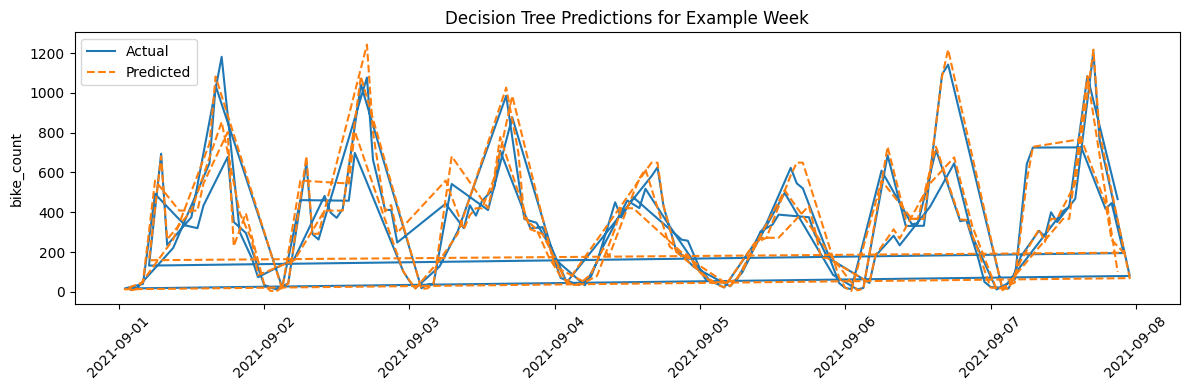

In [68]:
# Refit the model with the chosen depth from Section 7.3
regressor = DecisionTreeRegressor(max_depth=best_depth, random_state=42)
pipe_week = make_pipeline(preprocessor, regressor)
pipe_week.fit(X_train, y_train_log)

# Filter visualization period
mask = (
    (X_val["counter_name"] == "Totem 73 boulevard de Sébastopol S-N") &
    (X_val["date"] > "2021-09-01") &
    (X_val["date"] < "2021-09-08")
)

df_viz = X_val.loc[mask].copy()
y_viz_log = y_val_log.loc[mask]

# Actual bike counts
df_viz["bike_count"] = np.exp(y_viz_log.values) - 1

# Predicted bike counts (from decision tree, still in log-space → back-transform)
df_viz["bike_count_predicted"] = np.exp(pipe_week.predict(df_viz)) - 1

plt.figure(figsize=(12, 4))
plt.plot(df_viz["date"], df_viz["bike_count"], label="Actual")
plt.plot(df_viz["date"], df_viz["bike_count_predicted"], "--", label="Predicted")
plt.title("Decision Tree Predictions for Example Week")
plt.ylabel("bike_count")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


<span style="color:darkblue">

Over this week the decision tree follows the daily pattern very closely: peaks occur at the right times and magnitudes are mostly well captured, with only small over- and under-shoots. This confirms that a single tree already models key non-linear rush-hour effects better than the linear baselines.
</span>


---

# 8. Random Forest

Random Forests extend decision trees by averaging many trees trained on bootstrapped samples and random feature subsets.  
This typically reduces variance and improves generalization compared to a single Decision Tree.

In this section we:

1. Start with a small forest (`n_estimators = 3`) using the same tuned depth from Section 7 (`max_depth = 17`).  
2. Evaluate performance with a time-series cross-validation scheme.  
3. Increase the number of trees (`n_estimators = 7`) and study the effect on RMSE.  
4. Inspect the overall quality of predictions with a scatter plot.


### 8.1 Initial Trial: Random Forest with 3 Trees

We first train a Random Forest with only three trees (`n_estimators = 3`) and `max_depth = 17`.  
We keep the same feature set as for the Decision Tree: one-hot encoded dates and categorical variables, plus binary indicators (no weather variables for speed).


In [71]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import root_mean_squared_error
from time import time

### 8.1 Initial Trial: Random Forest with 3 Trees

best_depth = 17   # from Section 7

# ---- NEW: date encoding recreated here ----
date_encoder = FunctionTransformer(_encode_dates)
date_cols = _encode_dates(X_train[["date"]]).columns.tolist()
date_cols = [c for c in date_cols if c != "day"]
# -------------------------------------------

preprocessor = ColumnTransformer(
    [
        ("date", OneHotEncoder(handle_unknown="ignore"), date_cols),
        ("cat",  OneHotEncoder(handle_unknown="ignore"), categorical_cols),
        # ("num", numerical_encoder, numerical_corr_cols),  # skipped for speed
        ("binary", "passthrough", binary_cols),
    ]
)

regressor = RandomForestRegressor(
    random_state=42,
    max_depth=best_depth,
    n_estimators=3,
    n_jobs=-1,
)

start = time()
pipe_rf3 = make_pipeline(date_encoder, preprocessor, regressor)
pipe_rf3.fit(X_train, y_train_log)
elapsed_time = time() - start

print(f"Training time for random forest (3 trees): {elapsed_time:.2f} seconds")
print(f"Train RMSE (log) = {root_mean_squared_error(y_train_log, pipe_rf3.predict(X_train)):.2f}")
print(f"Valid RMSE (log) = {root_mean_squared_error(y_val_log,   pipe_rf3.predict(X_val)):.2f}")


Training time for random forest (3 trees): 10.15 seconds
Train RMSE (log) = 0.83
Valid RMSE (log) = 0.74


<span style="color:darkblue">

With only **3 trees**, the Random Forest achieves a **validation RMSE ≈ 0.74**, clearly better than Ridge (≈0.91) and comparable to the tuned single tree.  
This suggests that even a very small ensemble already stabilizes the tree predictions without adding much training time.
</span>


### 8.2 Time-Series Cross-Validation (3 Trees)

We now evaluate the 3-tree Random Forest using a time-series split, to check how robust its performance is across different periods of the year.

In [72]:
from sklearn.model_selection import TimeSeriesSplit, cross_val_score

### 8.2 Time-Series Cross-Validation (3 Trees)

cv = TimeSeriesSplit(n_splits=6)

scores = cross_val_score(
    pipe_rf3,
    X_train,
    y_train_log,
    cv=cv,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1,
)

print("RMSE per fold:", -scores)
print(f"RMSE (all folds): {-scores.mean():.3f} ± {(-scores).std():.3f}")


RMSE per fold: [0.86529139 1.02576376 0.78601554 1.05034453 0.94145666 1.37144017]
RMSE (all folds): 1.007 ± 0.186


<span style="color:darkblue">

With 3 trees, the Random Forest reaches a mean CV RMSE of ≈**1.01** with a spread of ±0.19.  
It improves slightly on Ridge (≈1.15) but is still less stable than the tuned single tree (≈0.95), showing that such a small forest is helpful but not yet fully robust.
</span>


### 8.3 Increasing the Number of Trees (7 Estimators)

We increase the number of trees to `n_estimators = 7` while keeping the tuned depth from Section 7 (`max_depth = 17`).   
More trees generally reduce variance but also increase training time compared with the 3-tree forest.

In [73]:
### 8.3 Increasing the Number of Trees (7 Estimators)

# Reuse date_encoder and preprocessor from 8.1
regressor_rf7 = RandomForestRegressor(
    random_state=42,
    max_depth=best_depth,   # best_depth = 17 from Section 7
    n_estimators=7,
    n_jobs=-1,
)

start = time()
pipe_rf7 = make_pipeline(date_encoder, preprocessor, regressor_rf7)
pipe_rf7.fit(X_train, y_train_log)
elapsed_time = time() - start

print(f"Training time for random forest (7 trees): {elapsed_time:.2f} seconds")
print(f"Train RMSE (log) = {root_mean_squared_error(y_train_log, pipe_rf7.predict(X_train)):.2f}")
print(f"Valid RMSE (log) = {root_mean_squared_error(y_val_log,   pipe_rf7.predict(X_val)):.2f}")

Training time for random forest (7 trees): 18.14 seconds
Train RMSE (log) = 0.83
Valid RMSE (log) = 0.73


<span style="color:darkblue">

With 7 trees, the Random Forest keeps the same train RMSE (≈0.83) but slightly improves validation RMSE to ≈0.73 compared to the 3-tree forest (≈0.74).  
This small gain, for roughly double the training time, suggests diminishing returns from simply adding more trees at this depth.
</span>


### 8.4 Scatter Plot: True vs Predicted (Log Space)

To visually assess the quality of the Random Forest predictions, we compare predicted `log_bike_count` values against the true values on the validation set.

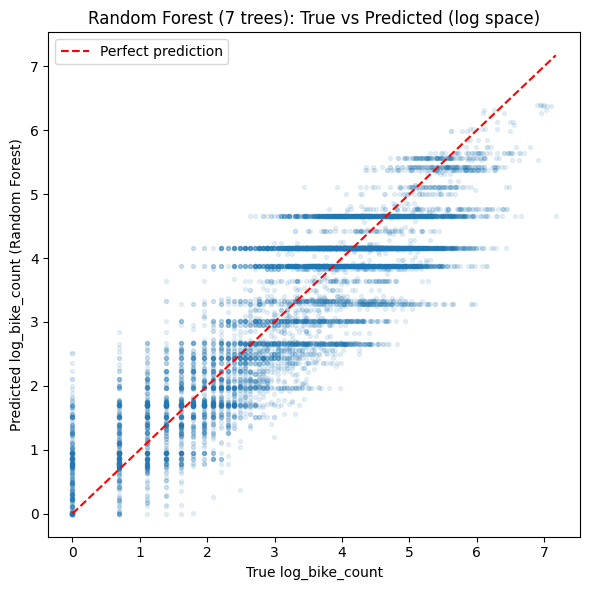

In [74]:
### 8.4 Scatter Plot: True vs Predicted (Log Space)

fig, ax = plt.subplots(figsize=(6, 6))

# Build a DataFrame for a random subset of validation points
df_viz = pd.DataFrame({
    "y_true": y_val_log,
    "y_pred": pipe_rf7.predict(X_val),
}).sample(10_000, random_state=0)

# Scatter plot
df_viz.plot.scatter(x="y_true", y="y_pred", s=8, alpha=0.1, ax=ax)
ax.set_xlabel("True log_bike_count")
ax.set_ylabel("Predicted log_bike_count (Random Forest)")
ax.set_title("Random Forest (7 trees): True vs Predicted (log space)")

# Add diagonal for reference
min_val = min(df_viz["y_true"].min(), df_viz["y_pred"].min())
max_val = max(df_viz["y_true"].max(), df_viz["y_pred"].max())
ax.plot([min_val, max_val], [min_val, max_val], "r--", label="Perfect prediction")
ax.legend()

plt.tight_layout()
plt.show()


<span style="color:darkblue">

Most points cluster around the diagonal, confirming that the Random Forest tracks log-bike counts fairly well.    
At higher demand levels the cloud drifts slightly below the line, indicating a mild tendency to underpredict the largest peaks.
</span>


---

# 10. Model Evaluation: Cross-Validation and Learning Curves

In the previous sections, we evaluated models mainly using a single temporal train–validation split.  
Here, we take a closer look at the **generalization performance** of the final Random Forest model by:

1. Performing **time-series cross-validation** on the training period.  
2. Plotting a **learning curve** to study how performance evolves with the size of the training set.

This helps assess the robustness of the model and whether additional data would likely improve performance.

### 10.1 Time-Series Cross-Validation

We evaluate the final Random Forest model (`max_depth = 17`, `n_estimators = 7`) using a **rolling time-series split** on the training set.  

- The input features and preprocessing are the same as in Section 8 (one-hot encoded dates and counters + binary indicators).  
- The target is `log_bike_count`, so RMSE is interpreted in **log space**.  

This mimics several “train on past → predict nearer future” scenarios and shows how stable the model performance is across different periods of the year.


In [76]:
from sklearn.model_selection import TimeSeriesSplit, cross_val_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import make_pipeline

best_depth = 17  # from Section 7 (Decision Tree tuning)

# Preprocessor for Random Forest (same as Section 8)
preprocessor = ColumnTransformer(
    [
        ("date", OneHotEncoder(handle_unknown="ignore"), date_cols),
        ("cat",  OneHotEncoder(handle_unknown="ignore"), categorical_cols),
        # final RF: no numerical weather features
        ("binary", "passthrough", binary_cols),
    ]
)

rf_regressor = RandomForestRegressor(
    random_state=42,
    max_depth=best_depth,
    n_estimators=7,
    n_jobs=-1,
)

rf_pipe = make_pipeline(date_encoder, preprocessor, rf_regressor)

tscv = TimeSeriesSplit(n_splits=3)

scores = cross_val_score(
    rf_pipe,
    X_train,
    y_train_log,  # log target
    cv=tscv,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1,
)

rmse_scores = -scores
print("RMSE per fold:", rmse_scores)
print(f"Mean RMSE = {rmse_scores.mean():.3f} ± {rmse_scores.std():.3f}")


RMSE per fold: [0.94294141 0.97651775 1.21486516]
Mean RMSE = 1.045 ± 0.121


<span style="color:darkblue">

Over three time-series folds, the final Random Forest (depth = 17, 7 trees) reaches a mean RMSE of ≈**1.05** with a moderate spread (±0.12).    
Performance is slightly better than Ridge (≈1.15) but still varies by period, showing that even the ensemble remains somewhat sensitive to seasonal patterns.   

</span>


### 10.2 Learning Curve for the Random Forest

To study how model performance scales with the amount of training data,   
we compute a learning curve for the final Random Forest model (`max_depth = 17`, `n_estimators = 7`).

We incrementally increase the training set size and measure:

- **Training RMSE** (fit quality on the training subset)  
- **Validation RMSE** (performance on the fixed validation period, in log space)

This reveals whether the model is data-limited or capacity-limited.


Training with 45645 samples (10% of training data)
Training with 114112 samples (25% of training data)
Training with 228225 samples (50% of training data)
Training with 342338 samples (75% of training data)
Training with 456451 samples (100% of training data)


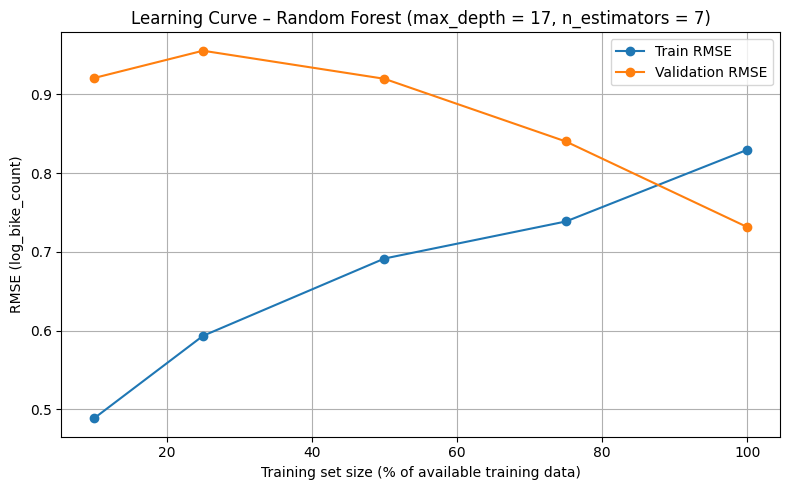

In [77]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import root_mean_squared_error

### 10.2 Learning Curve for the Random Forest

# Fractions of the training data to use
train_fracs = [0.1, 0.25, 0.5, 0.75, 1.0]

train_rmse = []
valid_rmse = []

for frac in train_fracs:
    n_samples = int(len(X_train) * frac)
    print(f"Training with {n_samples} samples ({frac*100:.0f}% of training data)")

    # Take the earliest n_samples to respect time order
    X_sub = X_train.iloc[:n_samples].copy()
    y_sub = y_train_log.iloc[:n_samples].copy()   # log target

    # Build a fresh pipeline for each fraction
    rf_regressor = RandomForestRegressor(
        random_state=42,
        max_depth=best_depth,   # best_depth = 17 from Section 7
        n_estimators=7,
        n_jobs=-1,
    )
    rf_pipe = make_pipeline(date_encoder, preprocessor, rf_regressor)

    rf_pipe.fit(X_sub, y_sub)

    # RMSE on the subset used for training (log space)
    y_sub_pred = rf_pipe.predict(X_sub)
    train_rmse.append(root_mean_squared_error(y_sub, y_sub_pred))

    # RMSE on the fixed validation set (log space)
    y_val_pred = rf_pipe.predict(X_val)
    valid_rmse.append(root_mean_squared_error(y_val_log, y_val_pred))

# Plot learning curve
plt.figure(figsize=(8, 5))
plt.plot(np.array(train_fracs) * 100, train_rmse, marker="o", label="Train RMSE")
plt.plot(np.array(train_fracs) * 100, valid_rmse, marker="o", label="Validation RMSE")
plt.xlabel("Training set size (% of available training data)")
plt.ylabel("RMSE (log_bike_count)")
plt.title("Learning Curve – Random Forest (max_depth = 17, n_estimators = 7)")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


<span style="color:darkblue">

As training size grows, train RMSE increases (0.49 → 0.83) while validation RMSE decreases (0.92 → 0.73) and the two curves get closer.   
This suggests the Random Forest benefits from more data and is not heavily overfitting; with the full dataset it still has a small bias but reasonably stable generalization.

</span>

---

# 11. Results and Discussion

In this section, we summarize and interpret the outcomes:

### Performance comparison
- OLS  
- Ridge Regression  
- Random Forest  

### Error patterns
Residual analysis to diagnose where models perform poorly (e.g., peak hours, extreme weather).

### Interpretation
Discuss why certain models performed better and what key factors drive bike rental demand.




---

# 12. Limitations and Future Work

### Limitations
- Dataset may not include all relevant drivers (events, holidays, bike availability).  
- Log-transform introduces mild bias when converting predictions back.  
- Standard regression models do not explicitly model temporal dependencies.  
- Random Forest lacks interpretability compared to linear models.  

### Future Work
- Add lagged features and rolling windows to capture temporal structure.  
- Explore time-series models (Prophet, ARIMA, LSTM).  
- Include richer weather and event-related datasets.  
- Investigate probabilistic forecasting for uncertainty quantification.  

---